In [ ]:
print("hello")

# 사용할 코드만 정리

In [1]:
# 도구 불러오기
import pandas as pd
import numpy as np
import glob
import os
import re
import ast
from glob import glob
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm

# 판다스 출력 제한 해제 
pd.set_option('display.max_rows', 100) # 최대 100행까지 생략 없이 출력
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', 1000)

In [2]:
# 원본 메타데이터 로드
df_meta = pd.read_csv("../../dataset/metadata.csv")

In [3]:
# 전처리 (시간/수치형(Capacity, Re, Rct)/file_num 파생)

def clean_parse_time(x):
    if pd.isna(x):
        return pd.NaT
    
    try:
        s = str(x)
        pattern = r"[-+]?\d*\.?\d+[eE][-+]?\d+|[-+]?\d+\.?\d*"
        parts = re.findall(pattern, s)
        
        if len(parts) < 3:
            return pd.NaT
        
        nums = [float(p) for p in parts]
        
        year   = int(nums[0])
        month  = int(nums[1])
        day    = int(nums[2])
        hour   = int(nums[3]) if len(nums) > 3 else 0
        minute = int(nums[4]) if len(nums) > 4 else 0
        
        # 핵심: round 제거
        second = int(nums[5]) if len(nums) > 5 else 0
        
        return pd.Timestamp(year=year, month=month, day=day,
                            hour=hour, minute=minute, second=second)
    
    except Exception as e:
        print(f"[파싱 실패] {x} | {e}")
        return pd.NaT

def clean_numeric(x):
    """수치형 데이터의 대괄호 제거 및 float 변환"""
    if pd.isna(x): return np.nan
    val = str(x).replace('[', '').replace(']', '').strip()
    try:
        return float(val)
    except:
        return np.nan

# --- [전처리 실행] ---
df = df_meta.copy()

# 1. 시간 데이터 정제 (소수점 초까지 완벽 대응)
df['start_time'] = df['start_time'].apply(clean_parse_time)

# 2. 수치형 데이터 정제 (Capacity, Re, Rct)
for col in ['Capacity', 'Re', 'Rct']:
    if col in df.columns:
        df[col] = df[col].apply(clean_numeric)

# 3. 물리적 순서 정렬 (파일 번호 기준)
df['file_num'] = df['filename'].str.extract(r'(\d+)').astype(int)
df = df.sort_values(['battery_id', 'file_num']).reset_index(drop=True)

# 최종 결과 검증
print(f"전체 데이터 개수: {len(df):,}개")
print(f"시간 결측치(NaT): {df['start_time'].isna().sum()}개")
print(f"수치형 결측치(Cap): {df['Capacity'].isna().sum()}개")


전체 데이터 개수: 7,565개
시간 결측치(NaT): 0개
수치형 결측치(Cap): 4796개


In [4]:
# 'B0005', 'B0006', 'B0007', 'B0018' 배터리 대상으로 충전 / 방전 / 임피던스별 data 구성하기
# SOH EOL RUL cycle 파생

# 대상 배터리 ID 리스트
target_battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']

# 데이터 저장할 폴더 경로
data_folder = "../../dataset/data"

# 데이터를 쌓아두기 위한 저장소(Dictionary) 생성
collected_data = {}


### 각 배터리별 EOL 사이클 번호를 먼저 파악 (RUL 계산용)
# SOH 80% 기준을 찾기 위해 메타데이터(df)에서 미리 계산
eol_dict = {}
for b_id in target_battery_ids:
    b_meta = df[(df['battery_id'] == b_id) & (df['type'] == 'discharge')].copy()
    if not b_meta.empty:
        initial_cap = b_meta['Capacity'].iloc[0] # 첫 번째 방전 용량
        # SOH 80% 이하인 첫 번째 행의 인덱스(순번) 찾기
        eol_idx = np.where((b_meta['Capacity'] / initial_cap) * 100 <= 80)[0]
        eol_dict[b_id] = eol_idx[0] + 1 if len(eol_idx) > 0 else np.nan

for battery_id in target_battery_ids:
    # 시간순 정렬 (매칭 오류 방지)
    filtered_df = df[df['battery_id'] == battery_id].sort_values('start_time')
    cycle_counters = {'charge': 1, 'discharge': 1, 'impedance': 1}
    
    # 기준 용량 정의 (해당 배터리의 첫 번째 방전 용량)
    dis_rows = filtered_df[filtered_df['type'] == 'discharge']
    first_cap = dis_rows['Capacity'].iloc[0] if not dis_rows.empty else None

    for _, row in filtered_df.iterrows():
        file_path = os.path.join(data_folder, row['filename'])

        if os.path.exists(file_path):
            temp_df = pd.read_csv(file_path)
            d_type = row['type']
            current_cycle = cycle_counters[d_type]

            # --- [1단계: 파생 변수 로직 정의] ---
            # SOH 정의: 오직 discharge 타입일 때만 해당 사이클의 용량으로 계산
            if d_type == 'discharge' and first_cap and pd.notnull(row['Capacity']):
                soh_val = (row['Capacity'] / first_cap) * 100
            else:
                soh_val = np.nan # 다른 타입은 우선 NaN 처리
            
            # EOL 정의: 미리 계산된 eol_dict 이용
            eol_val = eol_dict.get(battery_id)
            
            # RUL 정의: (사망 사이클 - 현재 사이클)
            rul_val = (eol_val - current_cycle) if pd.notnull(eol_val) else np.nan
            if pd.notnull(rul_val): rul_val = max(0, rul_val)

            # --- [2단계: 데이터프레임 열 추가] ---
            temp_df['start_time'] = row['start_time']
            temp_df['battery_id'] = battery_id
            temp_df['type'] = d_type
            temp_df['ambient_temperature'] = row['ambient_temperature']
            
            temp_df['cycle'] = current_cycle
            temp_df['SOH'] = soh_val  # 정의된 값 주입
            temp_df['EOL_cycle'] = eol_val
            temp_df['RUL'] = rul_val

            # 타입별 특화 데이터 추가
            if d_type == 'discharge':
                temp_df['Capacity'] = row['Capacity']
            elif d_type == 'impedance':
                temp_df['Re'] = row['Re']
                temp_df['Rct'] = row['Rct']

            # 카운터 증가 및 저장
            cycle_counters[d_type] += 1
            key = f"df_{d_type}_{battery_id}"
            if key not in collected_data:
                collected_data[key] = []
            collected_data[key].append(temp_df)

# --- [3단계: 데이터 통합 및 결측치 전파] ---
for key, df_list in collected_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # SOH 전파: discharge 파일들 사이의 간극(charge, impedance 등)을 메워줌
    # 단, 사용자님이 'discharge에만' 있길 원하신다면 이 섹션을 제외하면 됩니다.
    # 만약 모든 행에 SOH가 필요하다면 아래 ffill/bfill을 유지하세요.
    if 'SOH' in combined_df.columns:
        combined_df['SOH'] = combined_df['SOH'].ffill()
        combined_df['SOH'] = combined_df['SOH'].bfill()
    
    globals()[key] = combined_df
    print(f"✅ {key} 생성 완료 | 파일 {len(df_list)}개 통합 | 크기: {combined_df.shape} | SOH 결측치: {combined_df['SOH'].isnull().sum()} | cycle/SOH/EOL/RUL 파생 완료")


✅ df_charge_B0005 생성 완료 | 파일 170개 통합 | 크기: (541173, 14) | SOH 결측치: 541173 | cycle/SOH/EOL/RUL 파생 완료
✅ df_discharge_B0005 생성 완료 | 파일 168개 통합 | 크기: (50285, 15) | SOH 결측치: 0 | cycle/SOH/EOL/RUL 파생 완료
✅ df_impedance_B0005 생성 완료 | 파일 278개 통합 | 크기: (13344, 15) | SOH 결측치: 13344 | cycle/SOH/EOL/RUL 파생 완료
✅ df_charge_B0006 생성 완료 | 파일 170개 통합 | 크기: (541173, 14) | SOH 결측치: 541173 | cycle/SOH/EOL/RUL 파생 완료
✅ df_discharge_B0006 생성 완료 | 파일 168개 통합 | 크기: (50285, 15) | SOH 결측치: 0 | cycle/SOH/EOL/RUL 파생 완료
✅ df_impedance_B0006 생성 완료 | 파일 278개 통합 | 크기: (13344, 15) | SOH 결측치: 13344 | cycle/SOH/EOL/RUL 파생 완료
✅ df_charge_B0007 생성 완료 | 파일 170개 통합 | 크기: (541173, 14) | SOH 결측치: 541173 | cycle/SOH/EOL/RUL 파생 완료
✅ df_discharge_B0007 생성 완료 | 파일 168개 통합 | 크기: (50285, 15) | SOH 결측치: 0 | cycle/SOH/EOL/RUL 파생 완료
✅ df_impedance_B0007 생성 완료 | 파일 278개 통합 | 크기: (13344, 15) | SOH 결측치: 13344 | cycle/SOH/EOL/RUL 파생 완료
✅ df_charge_B0018 생성 완료 | 파일 134개 통합 | 크기: (279810, 14) | SOH 결측치: 279810 | cycle/SOH/EOL/RUL 파생 완료
✅ df_i

In [ ]:
# 대표로 하나 지정하여 null값 확인
df_discharge_B0005.info()

In [ ]:
# 대표로 하나 지정하여 null값 확인
df_charge_B0005.info()

In [ ]:
# 대표로 하나 지정하여 null값 확인
df_impedance_B0005.info()

In [ ]:
# 간단 확인
display(df_charge_B0006)
display(df_discharge_B0007)
display(df_impedance_B0005) 

# 분석

# discharge 분석

배터리 4개를 모두 합침


In [ ]:
# 1. 4개 배터리 데이터를 하나로 통합 (df_battery_discharge)

battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
all_dfs = []

for b_id in battery_ids:
    df_name = f"df_discharge_{b_id}"
    if df_name in globals():
        # .copy()를 써서 원본 데이터와 연결을 끊고 독립적인 복사본을 만들기
        temp_df = globals()[df_name].copy()
        temp_df['battery_id'] = b_id  # 배터리 식별자 추가
        all_dfs.append(temp_df)

# 통합 데이터프레임 생성
df_battery_discharge = pd.concat(all_dfs, ignore_index=True)

print(f"✅ discharge 통합 - 전체 행 개수: {len(df_battery_discharge)}")
print(f"포함된 배터리 id: {df_battery_discharge['battery_id'].unique()}")

In [ ]:
df_battery_discharge.columns

# charge 분석

배터리 4개를 모두 합침


In [ ]:
# 1. 충전(Charge) 데이터 통합
battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
all_charge_dfs = []

for b_id in battery_ids:
    df_name = f"df_charge_{b_id}"
    if df_name in globals():
        # 복사본 생성 및 ID 추가
        temp_df = globals()[df_name].copy()
        temp_df['battery_id'] = b_id
        all_charge_dfs.append(temp_df)

# 통합 데이터프레임 생성
df_battery_charge = pd.concat(all_charge_dfs, ignore_index=True)

print(f"charge 통합 - 전체 행 개수: {len(df_battery_charge)}")
print(f"포함된 배터리 id: {df_battery_charge['battery_id'].unique()}")

In [ ]:
df_battery_charge.columns

# impedance 분석

배터리 4개를 모두 합침

In [5]:
# 2. 임피던스(Impedance) 데이터 통합
battery_ids = ['B0005', 'B0006', 'B0007', 'B0018']
all_impedance_dfs = []

for b_id in battery_ids:
    df_name = f"df_impedance_{b_id}"
    if df_name in globals():
        # 복사본 생성 및 ID 추가
        temp_df = globals()[df_name].copy()
        temp_df['battery_id'] = b_id
        all_impedance_dfs.append(temp_df)

# 통합 데이터프레임 생성
df_battery_impedance = pd.concat(all_impedance_dfs, ignore_index=True)

print(f"Impedance 통합 - 전체 행 개수: {len(df_battery_impedance)}")
print(f"포함된 배터리 id: {df_battery_impedance['battery_id'].unique()}")

Impedance 통합 - 전체 행 개수: 42576
포함된 배터리 id: ['B0005' 'B0006' 'B0007' 'B0018']


In [6]:
df_battery_impedance

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,start_time,battery_id,type,ambient_temperature,cycle,SOH,EOL_cycle,RUL,Re,Rct
0,(-1+1j),(-1+1j),(1+0j),(-0.43892624830326377-0.107298295835479j),(0.07006937798290404-0.00047998469078178944j),2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456
1,(820.6094970703125-36.23455047607422j),(337.0914611816406-82.9207763671875j),(2.3204145178633437+0.4633045948164565j),(0.13008840651776496-0.19711481029612374j),(0.06817886114940203-0.001190040925296937j),2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456
2,(827.2421875-48.23122787475586j),(330.6315612792969-70.01371765136719j),(2.424192647592199+0.36746495469515333j),(0.058770560504133235+0.03330656583655633j),(0.06793257733714593-5.6826811936507056e-05j),2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456
3,(827.1934814453125-56.195716857910156j),(330.8086242675781-61.73442459106445j),(2.4470021712116985+0.28677775364826635j),(0.0058135116366746726-0.060546548141956195j),(0.06691839226387165-0.0008787264015490232j),2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456
4,(824.9295043945312-53.241477966308594j),(332.68267822265625-57.62901306152344j),(2.434304977711638+0.2616460702282485j),(0.12608106668700975-0.09044390544679616j),(0.06807105294348659-0.0001974802021297548j),2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42571,(904.7120361328125-74.72950744628906j),(241.7991485595703+102.57585144042969j),(3.0598251673347208-1.6070928353528435j),(0.22985770749814396-0.05115204671227994j),NaN,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959
42572,(909.7190551757812-12.444096565246582j),(221.4372100830078+121.69818115234375j),(3.1315151505694767-1.7772252210594424j),(0.25007239126477454-0.05690264463771955j),NaN,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959
42573,(912.663330078125+109.28048706054688j),(180.153076171875+146.0713653564453j),(3.3533228257748786-2.112336712020755j),(0.27499289029885726-0.06062889284227303j),NaN,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959
42574,(879.797607421875+279.95587158203125j),(138.46356201171875+156.1693878173828j),(3.800195404173965-2.264265874134555j),(0.3054443217280123-0.06054666552299647j),NaN,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959


In [7]:
df_battery_impedance.columns

Index(['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance', 'start_time', 'battery_id', 'type', 'ambient_temperature', 'cycle', 'SOH', 'EOL_cycle', 'RUL', 'Re', 'Rct'], dtype='object')

In [9]:
df_battery_impedance.describe

<bound method NDFrame.describe of                                  Sense_current                          Battery_current                              Current_ratio                              Battery_impedance                            Rectified_Impedance          start_time battery_id       type  ambient_temperature  cycle  SOH  EOL_cycle  RUL        Re       Rct
0                                      (-1+1j)                                  (-1+1j)                                     (1+0j)      (-0.43892624830326377-0.107298295835479j)  (0.07006937798290404-0.00047998469078178944j) 2008-04-18 20:55:29      B0005  impedance                   24      1  NaN        101  100  0.044669  0.069456
1       (820.6094970703125-36.23455047607422j)    (337.0914611816406-82.9207763671875j)   (2.3204145178633437+0.4633045948164565j)     (0.13008840651776496-0.19711481029612374j)    (0.06817886114940203-0.001190040925296937j) 2008-04-18 20:55:29      B0005  impedance                   24      1

In [8]:
df_battery_impedance.describe()

,start_time,ambient_temperature,cycle,SOH,EOL_cycle,RUL,Re,Rct
count,42576,42576.0,42576.000000,0.0,42576.000000,42576.000000,42576.000000,42576.000000
mean,2008-05-14 03:21:23.356257024,24.0,132.777903,NaN,94.118377,19.222097,0.059270,0.082810
min,2008-04-18 20:55:29,24.0,1.000000,NaN,61.000000,0.000000,0.035920,0.060073
25%,2008-05-01 17:39:20,24.0,57.000000,NaN,61.000000,0.000000,0.050548,0.074583
50%,2008-05-11 07:47:30,24.0,131.000000,NaN,101.000000,0.000000,0.059556,0.082370
75%,2008-05-20 20:18:35,24.0,205.000000,NaN,124.000000,34.000000,0.065843,0.090408
max,2008-08-20 01:34:44,24.0,278.000000,NaN,124.000000,123.000000,0.079141,0.106684
std,NaN,0.0,82.344538,NaN,25.696571,30.898443,0.009766,0.010388


In [10]:
df_battery_impedance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42576 entries, 0 to 42575
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Sense_current        42576 non-null  object        
 1   Battery_current      42576 non-null  object        
 2   Current_ratio        42576 non-null  object        
 3   Battery_impedance    42576 non-null  object        
 4   Rectified_Impedance  34593 non-null  object        
 5   start_time           42576 non-null  datetime64[ns]
 6   battery_id           42576 non-null  object        
 7   type                 42576 non-null  object        
 8   ambient_temperature  42576 non-null  int64         
 9   cycle                42576 non-null  int64         
 10  SOH                  0 non-null      float64       
 11  EOL_cycle            42576 non-null  int64         
 12  RUL                  42576 non-null  int64         
 13  Re                   42576 non-

# 복소수 컬럼에서 유의한 컬럼 7개 파생

In [12]:
# 1. 대상 원본 컬럼 리스트 (기존 변환된 complex 타입 기준)
complex_cols = ['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']

# 2. 7개 핵심 파생 컬럼만 생성 (에러 방지용 타입 변환 추가)

# 문자열로 변해버린 컬럼을 다시 복소수(complex) 타입으로 변환하는 함수
def to_complex(x):
    if pd.isna(x) or x == '': return np.nan
    try:
        return complex(x) if isinstance(x, str) else x
    except:
        return np.nan

# (A) 전류 및 비율의 '크기(Magnitude)' 계산 전 타입 변환 적용
for col in ['Sense_current', 'Battery_current', 'Current_ratio']:
    df_battery_impedance[col] = df_battery_impedance[col].apply(to_complex)

df_battery_impedance['Sense_current_mag'] = df_battery_impedance['Sense_current'].apply(abs)
df_battery_impedance['Battery_current_mag'] = df_battery_impedance['Battery_current'].apply(abs)
df_battery_impedance['Current_ratio_mag'] = df_battery_impedance['Current_ratio'].apply(abs)

# (B) 임피던스 컬럼들도 동일하게 타입 변환 후 계산
for col in ['Battery_impedance', 'Rectified_Impedance']:
    df_battery_impedance[col] = df_battery_impedance[col].apply(to_complex)

df_battery_impedance['Battery_impedance_real'] = df_battery_impedance['Battery_impedance'].apply(lambda x: x.real if pd.notnull(x) else np.nan)
df_battery_impedance['Rectified_Impedance_real'] = df_battery_impedance['Rectified_Impedance'].apply(lambda x: x.real if pd.notnull(x) else np.nan)

# (C) 위상(Phase) 계산
df_battery_impedance['Battery_impedance_phase'] = df_battery_impedance['Battery_impedance'].apply(lambda x: np.angle(x, deg=True) if pd.notnull(x) else np.nan)
df_battery_impedance['Rectified_Impedance_phase'] = df_battery_impedance['Rectified_Impedance'].apply(lambda x: np.angle(x, deg=True) if pd.notnull(x) else np.nan)
# 3. 불필요하게 생성되었던 나머지 파생 컬럼 삭제
all_cols = df_battery_impedance.columns.tolist()
keep_cols = complex_cols + [
    'start_time', 'battery_id', 'type', 'ambient_temperature', 'cycle', 
    'SOH', 'EOL_cycle', 'RUL', 'Re', 'Rct',
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]
df_battery_impedance = df_battery_impedance[keep_cols]

# 결과 확인
print(df_battery_impedance.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42576 entries, 0 to 42575
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Sense_current              42576 non-null  complex128    
 1   Battery_current            42576 non-null  complex128    
 2   Current_ratio              42576 non-null  complex128    
 3   Battery_impedance          42576 non-null  complex128    
 4   Rectified_Impedance        34593 non-null  complex128    
 5   start_time                 42576 non-null  datetime64[ns]
 6   battery_id                 42576 non-null  object        
 7   type                       42576 non-null  object        
 8   ambient_temperature        42576 non-null  int64         
 9   cycle                      42576 non-null  int64         
 10  SOH                        0 non-null      float64       
 11  EOL_cycle                  42576 non-null  int64         
 12  RUL 

In [13]:
df_battery_impedance.head()

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,start_time,battery_id,type,ambient_temperature,cycle,SOH,EOL_cycle,RUL,Re,Rct,Sense_current_mag,Battery_current_mag,Current_ratio_mag,Battery_impedance_real,Battery_impedance_phase,Rectified_Impedance_real,Rectified_Impedance_phase
0,-1.000000+ 1.000000j,-1.000000+ 1.000000j,1.000000+0.000000j,-0.438926-0.107298j,0.070069-0.000480j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,1.414214,1.414214,1.000000,-0.438926,-166.263090,0.070069,-0.392478
1,820.609497- 36.234550j,337.091461- 82.920776j,2.320415+0.463305j,0.130088-0.197115j,0.068179-0.001190j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,821.409088,347.140474,2.366215,0.130088,-56.576681,0.068179,-0.999979
2,827.242188- 48.231228j,330.631561- 70.013718j,2.424193+0.367465j,0.058771+0.033307j,0.067933-0.000057j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,828.647023,337.963238,2.451885,0.058771,29.541179,0.067933,-0.047929
3,827.193481- 56.195717j,330.808624- 61.734425j,2.447002+0.286778j,0.005814-0.060547j,0.066918-0.000879j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,829.100123,336.519665,2.463749,0.005814,-84.515432,0.066918,-0.752326
4,824.929504- 53.241478j,332.682678- 57.629013j,2.434305+0.261646j,0.126081-0.090444j,0.068071-0.000197j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,826.645838,337.637183,2.448326,0.126081,-35.653661,0.068071,-0.166220


In [14]:
# 수치형칼럼 describe()

# 1. ambient_temperature와 SOH를 제외한 11개 컬럼 정의
selected_cols = [
    'cycle', 'EOL_cycle', 'RUL', 'Re', 'Rct',
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]

# 2. 요약 통계량 확인 (가로로 길게 보는 T 사용)
print("--- 11개 핵심 컬럼 요약 통계 ---")
display(df_battery_impedance[selected_cols].describe().T)

# 3. 실제 데이터 행(Row) 확인 (상위 5개)
print("\n--- 실제 데이터 행 확인 ---")
display(df_battery_impedance[selected_cols].head())

"""
물리적 오류 및 이상치 (전처리 필요)
Battery_impedance_real (min: -4.908): 저항의 최소값이 음수입니다. 물리적으로 저항이 0보다 작을 수는 없으므로, 이 행들은 센서 에러이거나 계산 오류입니다. (정상 범위는 보통 0.1~0.3 내외)
Battery_impedance_phase (min: -179.3, max: 179.4): 위상각이 180도 가까이 튀었습니다. 배터리 내부 화학 반응은 보통 -20° ~ 5° 사이에서 움직여야 합니다. 180도 차이가 난다는 건 신호가 완전히 뒤집힌(Inverted) 쓰레기 데이터라는 뜻입니다.
Current_ratio_mag (max: 14.25): 평균(2.62)에 비해 최대값이 너무 큽니다. 전류 비율이 14배까지 치솟았다는 것은 전류 센서 중 하나가 순간적으로 먹통이 되었을 가능성이 큽니다

배터리 노화 및 수명 지표 : 배터리의 상태를 나타내는 지표들의 분포입니다.
Re & Rct: Re(전해질 저항) 평균: 0.059, Rct(전하 전달 저항) 평균: 0.082입니다.
두 값 모두 표준편차(std)가 매우 작아 비교적 안정적으로 보이지만, Rct가 Re보다 평균적으로 높으므로 배터리 내부 화학 반응 저항이 지배적임을 알 수 있습니다.
cycle: 최소 1에서 최대 278까지 분포되어 있습니다. 배터리 하나가 수명을 다할 때까지의 전 과정을 담고 있는 데이터셋임을 보여줍니다.
RUL (Remaining Useful Life): 평균 19회 정도 남았으며, 75% 지점이 34회인 것으로 보아 수명이 얼마 남지 않은 배터리 데이터가 다수 포함되어 있습니다.

전류 센서 데이터 (_mag)
Sense_current_mag (834.4) vs Battery_current_mag (328.1):
센서에서 측정된 전류의 크기가 배터리에 흐르는 실전류보다 약 2.5배 정도 크게 찍힙니다.
이는 앞서 나온 Current_ratio_mag 평균인 2.62와 일치하며, 시스템의 전류 증폭 비율이 약 2.6배로 설정되어 있음을 시사합니다.

보정 데이터 (Rectified_Impedance)
 count (34,593): 다른 컬럼(42,576)에 비해 약 **8,000개 정도 데이터가 부족(NaN)**합니다. 이 부분은 결측치 처리를 하지 않기로 하셨으니, 분석 시 이 빈칸을 감안해야 합니다.
Rectified_Impedance_phase: 보정 전(Battery_impedance_phase)에는 -179~179로 날뛰던 위상값이 보정 후에는 -4.8 ~ 3.9 사이로 매우 안정되었습니다. 보정 알고리즘이 튀는 위상값을 잘 잡아낸 것으로 보입니다.
"""

--- 11개 핵심 컬럼 요약 통계 ---


,count,mean,std,min,25%,50%,75%,max
cycle,42576.0,132.777903,82.344538,1.000000,57.000000,131.000000,205.000000,278.000000
EOL_cycle,42576.0,94.118377,25.696571,61.000000,61.000000,101.000000,124.000000,124.000000
RUL,42576.0,19.222097,30.898443,0.000000,0.000000,0.000000,34.000000,123.000000
Re,42576.0,0.059270,0.009766,0.035920,0.050548,0.059556,0.065843,0.079141
Rct,42576.0,0.082810,0.010388,0.060073,0.074583,0.082370,0.090408,0.106684
Sense_current_mag,42576.0,834.404475,47.161794,1.414214,812.574383,825.028898,838.761364,941.254791
Battery_current_mag,42576.0,328.108744,45.159961,1.414214,327.250013,340.369347,352.822024,561.118838
Current_ratio_mag,42576.0,2.628084,0.665809,0.871108,2.302610,2.423716,2.563533,14.256392
Battery_impedance_real,42576.0,0.200465,0.080168,-4.908957,0.182714,0.196942,0.212140,2.585825
Battery_impedance_phase,42576.0,-4.657252,16.238085,-179.373434,-9.698402,-1.127362,0.837997,179.430286



--- 실제 데이터 행 확인 ---


,cycle,EOL_cycle,RUL,Re,Rct,Sense_current_mag,Battery_current_mag,Current_ratio_mag,Battery_impedance_real,Battery_impedance_phase,Rectified_Impedance_real,Rectified_Impedance_phase
0,1,101,100,0.044669,0.069456,1.414214,1.414214,1.000000,-0.438926,-166.263090,0.070069,-0.392478
1,1,101,100,0.044669,0.069456,821.409088,347.140474,2.366215,0.130088,-56.576681,0.068179,-0.999979
2,1,101,100,0.044669,0.069456,828.647023,337.963238,2.451885,0.058771,29.541179,0.067933,-0.047929
3,1,101,100,0.044669,0.069456,829.100123,336.519665,2.463749,0.005814,-84.515432,0.066918,-0.752326
4,1,101,100,0.044669,0.069456,826.645838,337.637183,2.448326,0.126081,-35.653661,0.068071,-0.166220


'\n물리적 오류 및 이상치 (전처리 필요)\nBattery_impedance_real (min: -4.908): 저항의 최소값이 음수입니다. 물리적으로 저항이 0보다 작을 수는 없으므로, 이 행들은 센서 에러이거나 계산 오류입니다. (정상 범위는 보통 0.1~0.3 내외)\nBattery_impedance_phase (min: -179.3, max: 179.4): 위상각이 180도 가까이 튀었습니다. 배터리 내부 화학 반응은 보통 -20° ~ 5° 사이에서 움직여야 합니다. 180도 차이가 난다는 건 신호가 완전히 뒤집힌(Inverted) 쓰레기 데이터라는 뜻입니다.\nCurrent_ratio_mag (max: 14.25): 평균(2.62)에 비해 최대값이 너무 큽니다. 전류 비율이 14배까지 치솟았다는 것은 전류 센서 중 하나가 순간적으로 먹통이 되었을 가능성이 큽니다\n\n배터리 노화 및 수명 지표 : 배터리의 상태를 나타내는 지표들의 분포입니다.\nRe & Rct: Re(전해질 저항) 평균: 0.059, Rct(전하 전달 저항) 평균: 0.082입니다.\n두 값 모두 표준편차(std)가 매우 작아 비교적 안정적으로 보이지만, Rct가 Re보다 평균적으로 높으므로 배터리 내부 화학 반응 저항이 지배적임을 알 수 있습니다.\ncycle: 최소 1에서 최대 278까지 분포되어 있습니다. 배터리 하나가 수명을 다할 때까지의 전 과정을 담고 있는 데이터셋임을 보여줍니다.\nRUL (Remaining Useful Life): 평균 19회 정도 남았으며, 75% 지점이 34회인 것으로 보아 수명이 얼마 남지 않은 배터리 데이터가 다수 포함되어 있습니다.\n\n전류 센서 데이터 (_mag)\nSense_current_mag (834.4) vs Battery_current_mag (328.1):\n센서에서 측정된 전류의 크기가 배터리에 흐르는 실전류보다 약 2.5배 정도 크게 찍힙니다.\n이는 앞서 나온 Current_ratio_mag 평균인 2.62와 일치하며, 시스

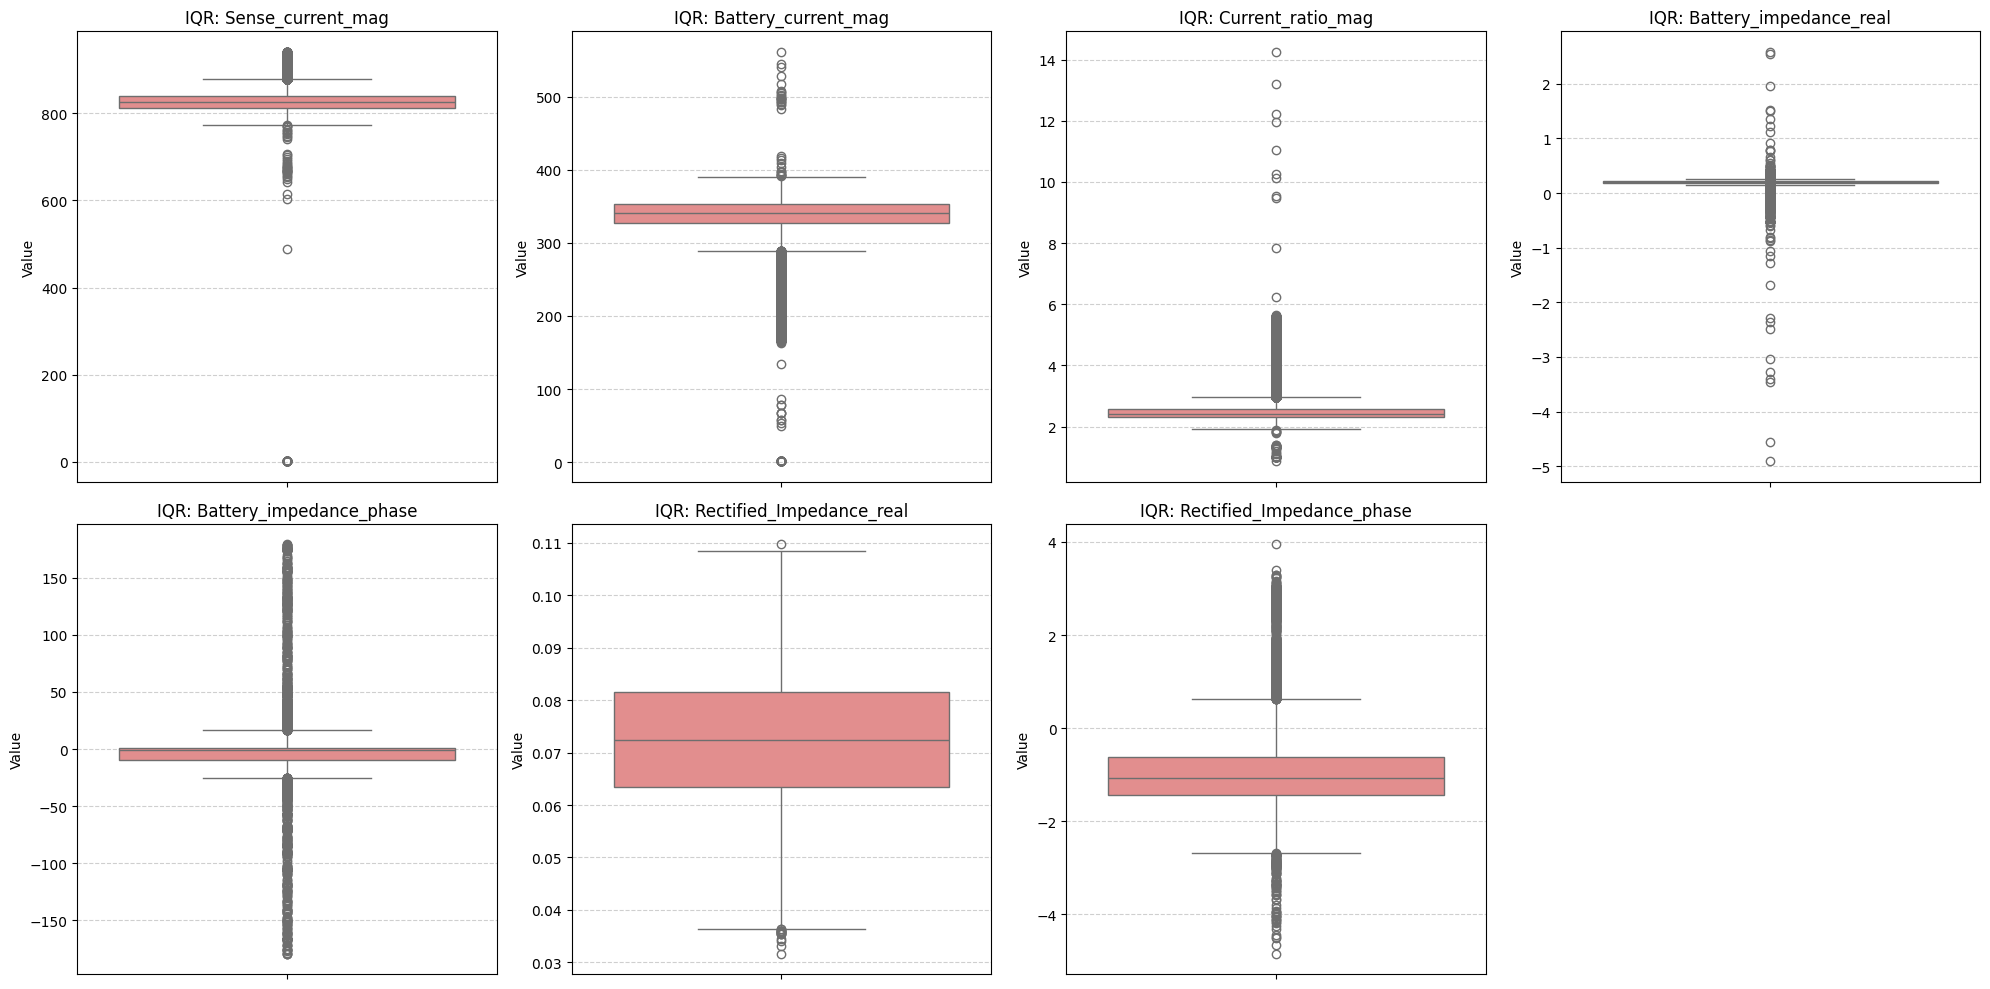

In [15]:
# 파생 칼럼에 대한 IQR

# 1. 시각화할 파생 컬럼 리스트
target_cols = [
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

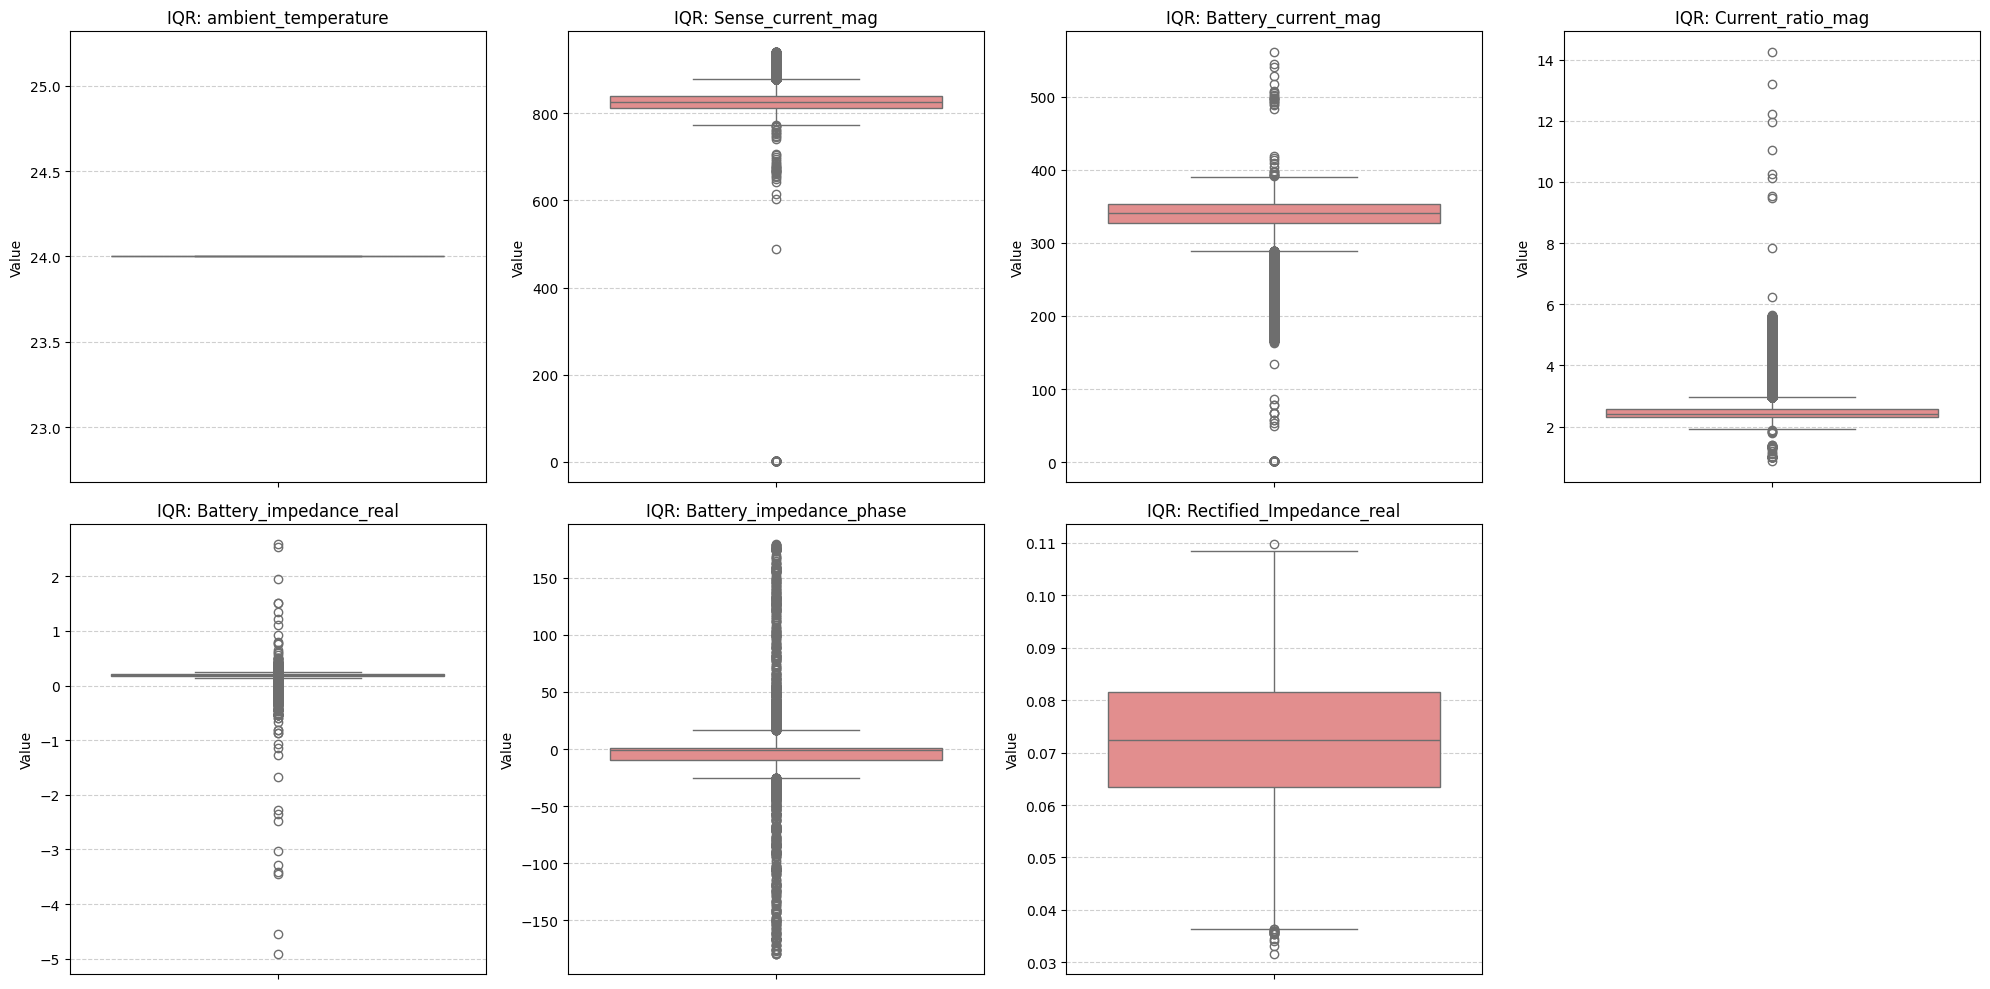

In [16]:
# 기본 칼럼에 대한 IQR

# 1. 시각화할 컬럼 리스트
target_cols = [
    'ambient_temperature', 'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]
selected_cols = [
    'cycle', 'EOL_cycle', 'RUL', 'Re', 'Rct',
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

In [ ]:
# 수치형의 IQR 확인

# 1. 시각화가 가능한 수치형(float, int) 컬럼만 선택
# 복소수(complex)는 절대값(abs) 처리를 해야 시각화가 가능하므로 제외하거나 변환 후 포함해야 함
numeric_cols = df_battery_impedance.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 2. 서브플롯 설정 (컬럼 개수에 맞춰 행/열 계산)
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # 결측치(NaN)를 제외하고 박스 플롯 그리기
    sns.boxplot(y=df_battery_impedance[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

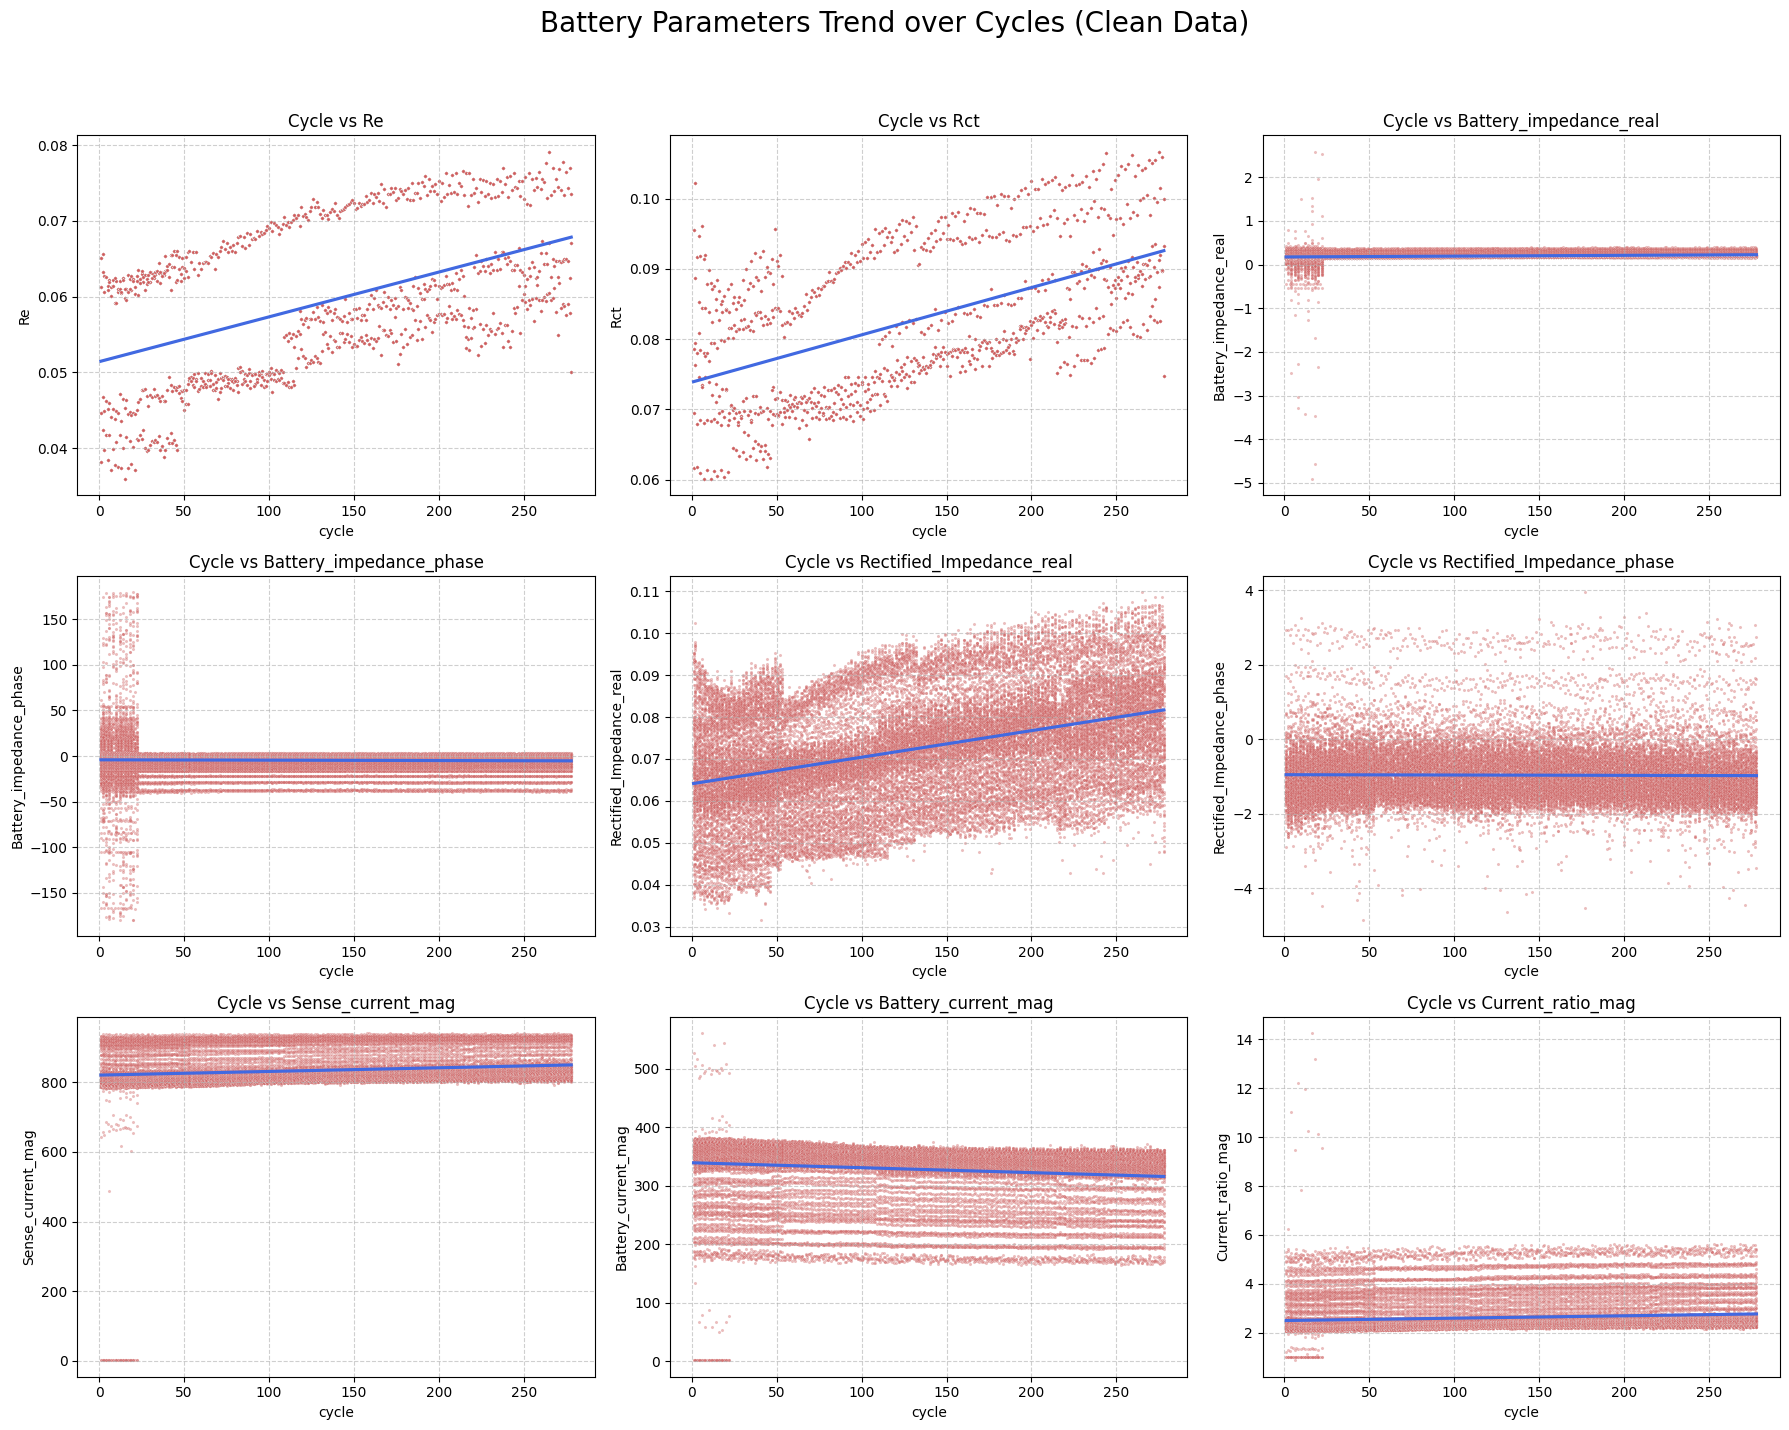

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 9개 컬럼 리스트 (기존 7개 + Re, Rct)
plot_cols = [
    'Re', 'Rct', 'Battery_impedance_real', 'Battery_impedance_phase',
    'Rectified_Impedance_real', 'Rectified_Impedance_phase',
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag'
]

# 그래프 설정 (3행 3열)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Battery Parameters Trend over Cycles (Clean Data)', fontsize=20)

axes = axes.flatten()

for i, col in enumerate(plot_cols):
    # 산점도(Scatter)로 추세 확인 (점 크기 조절 s=5)
    sns.scatterplot(data=df_battery_impedance, x='cycle', y=col, 
                    ax=axes[i], s=5, alpha=0.4, color='indianred')
    
    # 추세선(Trendline) 추가 - 데이터의 흐름을 더 잘 보게 해줍니다.
    sns.regplot(data=df_battery_impedance, x='cycle', y=col, 
                ax=axes[i], scatter=False, color='royalblue')
    
    axes[i].set_title(f'Cycle vs {col}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

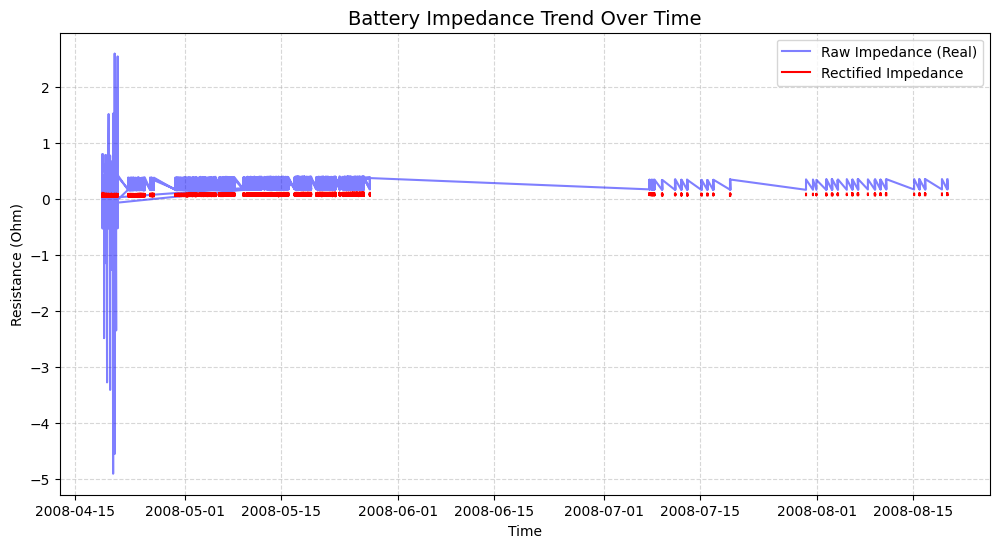

In [20]:
# 시간에 따른 임피던스(저항) 변화 확인
plt.figure(figsize=(12, 6))

# 1. 원본 임피던스의 실수부 (저항)
plt.plot(df_battery_impedance['start_time'], 
         df_battery_impedance['Battery_impedance_real'], 
         label='Raw Impedance (Real)', 
         alpha=0.5, 
         color='blue')

# 2. 보정된 임피던스의 실수부 (Rectified)
plt.plot(df_battery_impedance['start_time'], 
         df_battery_impedance['Rectified_Impedance_real'], 
         label='Rectified Impedance', 
         color='red', 
         linewidth=1.5)

plt.title('Battery Impedance Trend Over Time', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Resistance (Ohm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 임피던스 전처리

In [22]:
# 전처리 하기

# df_battery_impedance를 독립된 데이터프레임으로 확실히 만듭니다.
df_battery_impedance = df_battery_impedance.copy()

# 'is_valid'라는 체크용 컬럼 생성 (기본값 True)
df_battery_impedance['is_valid'] = True

# 1. 저항이 음수인 경우 (물리적 오류)
df_battery_impedance.loc[df_battery_impedance['Battery_impedance_real'] <= 0, 'is_valid'] = False

# 2. 위상각이 너무 튀는 경우 (측정 오류)
# 배터리 특성상 -45도 ~ 10도 범위를 벗어나면 신뢰하기 어렵습니다.
df_battery_impedance.loc[(df_battery_impedance['Battery_impedance_phase'] < -45) | 
                         (df_battery_impedance['Battery_impedance_phase'] > 20), 'is_valid'] = False

print(f"정상 데이터: {df_battery_impedance['is_valid'].sum()}개")
print(f"이상 데이터(보류): {(~df_battery_impedance['is_valid']).sum()}개")

정상 데이터: 41527개
이상 데이터(보류): 1049개


In [23]:
# 보정 데이터가 있는 것만 따로 보기 (원본 유지)
df_rectified_only = df_battery_impedance[df_battery_impedance['Rectified_Impedance'].notnull()]

In [30]:
df_battery_impedance

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,start_time,battery_id,type,ambient_temperature,cycle,SOH,EOL_cycle,RUL,Re,Rct,Sense_current_mag,Battery_current_mag,Current_ratio_mag,Battery_impedance_real,Battery_impedance_phase,Rectified_Impedance_real,Rectified_Impedance_phase,is_valid
0,-1.000000+ 1.000000j,-1.000000+ 1.000000j,1.000000+0.000000j,-0.438926-0.107298j,0.070069-0.000480j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,1.414214,1.414214,1.000000,-0.438926,-166.263090,0.070069,-0.392478,False
1,820.609497- 36.234550j,337.091461- 82.920776j,2.320415+0.463305j,0.130088-0.197115j,0.068179-0.001190j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,821.409088,347.140474,2.366215,0.130088,-56.576681,0.068179,-0.999979,False
2,827.242188- 48.231228j,330.631561- 70.013718j,2.424193+0.367465j,0.058771+0.033307j,0.067933-0.000057j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,828.647023,337.963238,2.451885,0.058771,29.541179,0.067933,-0.047929,False
3,827.193481- 56.195717j,330.808624- 61.734425j,2.447002+0.286778j,0.005814-0.060547j,0.066918-0.000879j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,829.100123,336.519665,2.463749,0.005814,-84.515432,0.066918,-0.752326,False
4,824.929504- 53.241478j,332.682678- 57.629013j,2.434305+0.261646j,0.126081-0.090444j,0.068071-0.000197j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,826.645838,337.637183,2.448326,0.126081,-35.653661,0.068071,-0.166220,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42571,904.712036- 74.729507j,241.799149+102.575851j,3.059825-1.607093j,0.229858-0.051152j,NaN+0.000000j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,907.793130,262.656874,3.456194,0.229858,-12.546041,NaN,NaN,True
42572,909.719055- 12.444097j,221.437210+121.698181j,3.131515-1.777225j,0.250072-0.056903j,NaN+0.000000j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,909.804163,252.675454,3.600683,0.250072,-12.819082,NaN,NaN,True
42573,912.663330+109.280487j,180.153076+146.071365j,3.353323-2.112337j,0.274993-0.060629j,NaN+0.000000j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,919.182560,231.930970,3.963173,0.274993,-12.433342,NaN,NaN,True
42574,879.797607+279.955872j,138.463562+156.169388j,3.800195-2.264266j,0.305444-0.060547j,NaN+0.000000j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,923.265466,208.712807,4.423617,0.305444,-11.212104,NaN,NaN,True


In [31]:
display(df_battery_impedance[selected_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
cycle,42576.0,132.777903,82.344538,1.000000,57.000000,131.000000,205.000000,278.000000
EOL_cycle,42576.0,94.118377,25.696571,61.000000,61.000000,101.000000,124.000000,124.000000
RUL,42576.0,19.222097,30.898443,0.000000,0.000000,0.000000,34.000000,123.000000
Re,42576.0,0.059270,0.009766,0.035920,0.050548,0.059556,0.065843,0.079141
Rct,42576.0,0.082810,0.010388,0.060073,0.074583,0.082370,0.090408,0.106684


In [32]:
df_battery_impedance_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33657 entries, 4 to 42566
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Sense_current              33657 non-null  complex128    
 1   Battery_current            33657 non-null  complex128    
 2   Current_ratio              33657 non-null  complex128    
 3   Battery_impedance          33657 non-null  complex128    
 4   Rectified_Impedance        33657 non-null  complex128    
 5   start_time                 33657 non-null  datetime64[ns]
 6   battery_id                 33657 non-null  object        
 7   type                       33657 non-null  object        
 8   ambient_temperature        33657 non-null  int64         
 9   cycle                      33657 non-null  int64         
 10  SOH                        0 non-null      float64       
 11  EOL_cycle                  33657 non-null  int64         
 12  RUL      

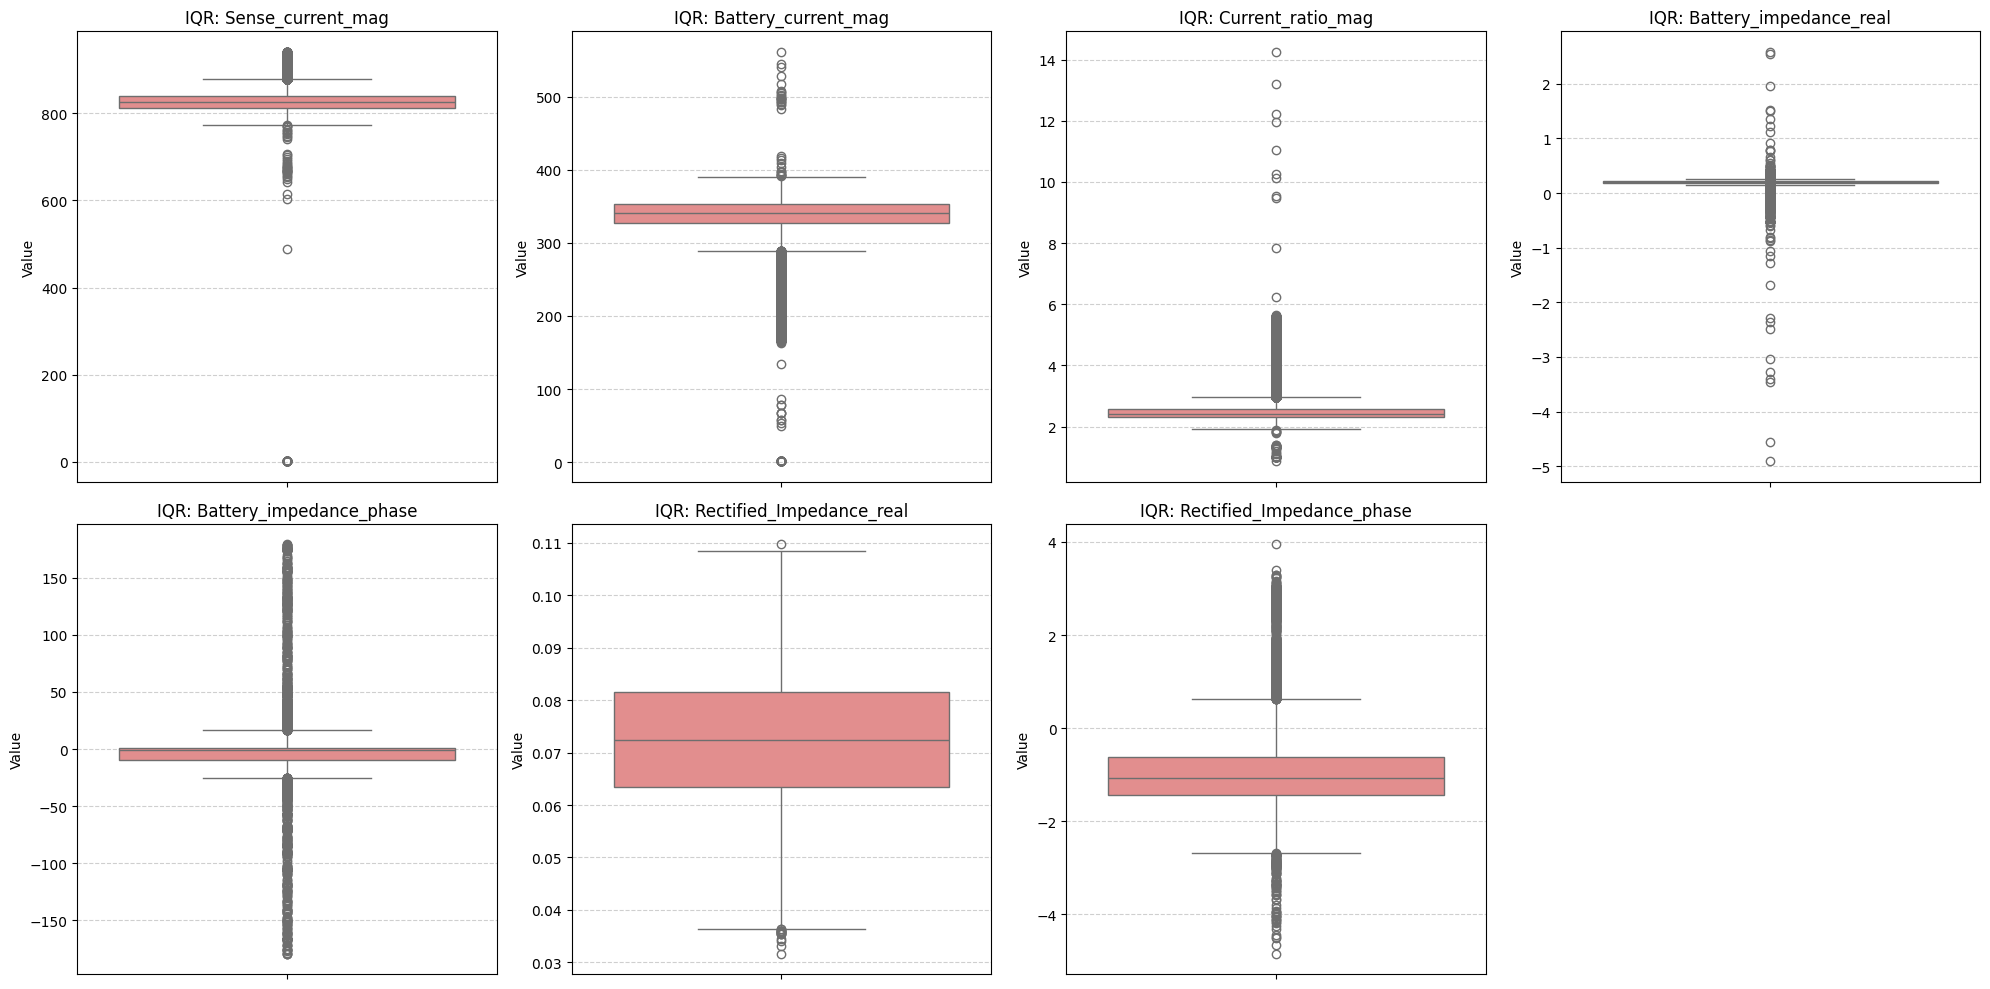

In [33]:
# 파생 칼럼에 대한 IQR

# 1. 시각화할 파생 컬럼 리스트
target_cols = [
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

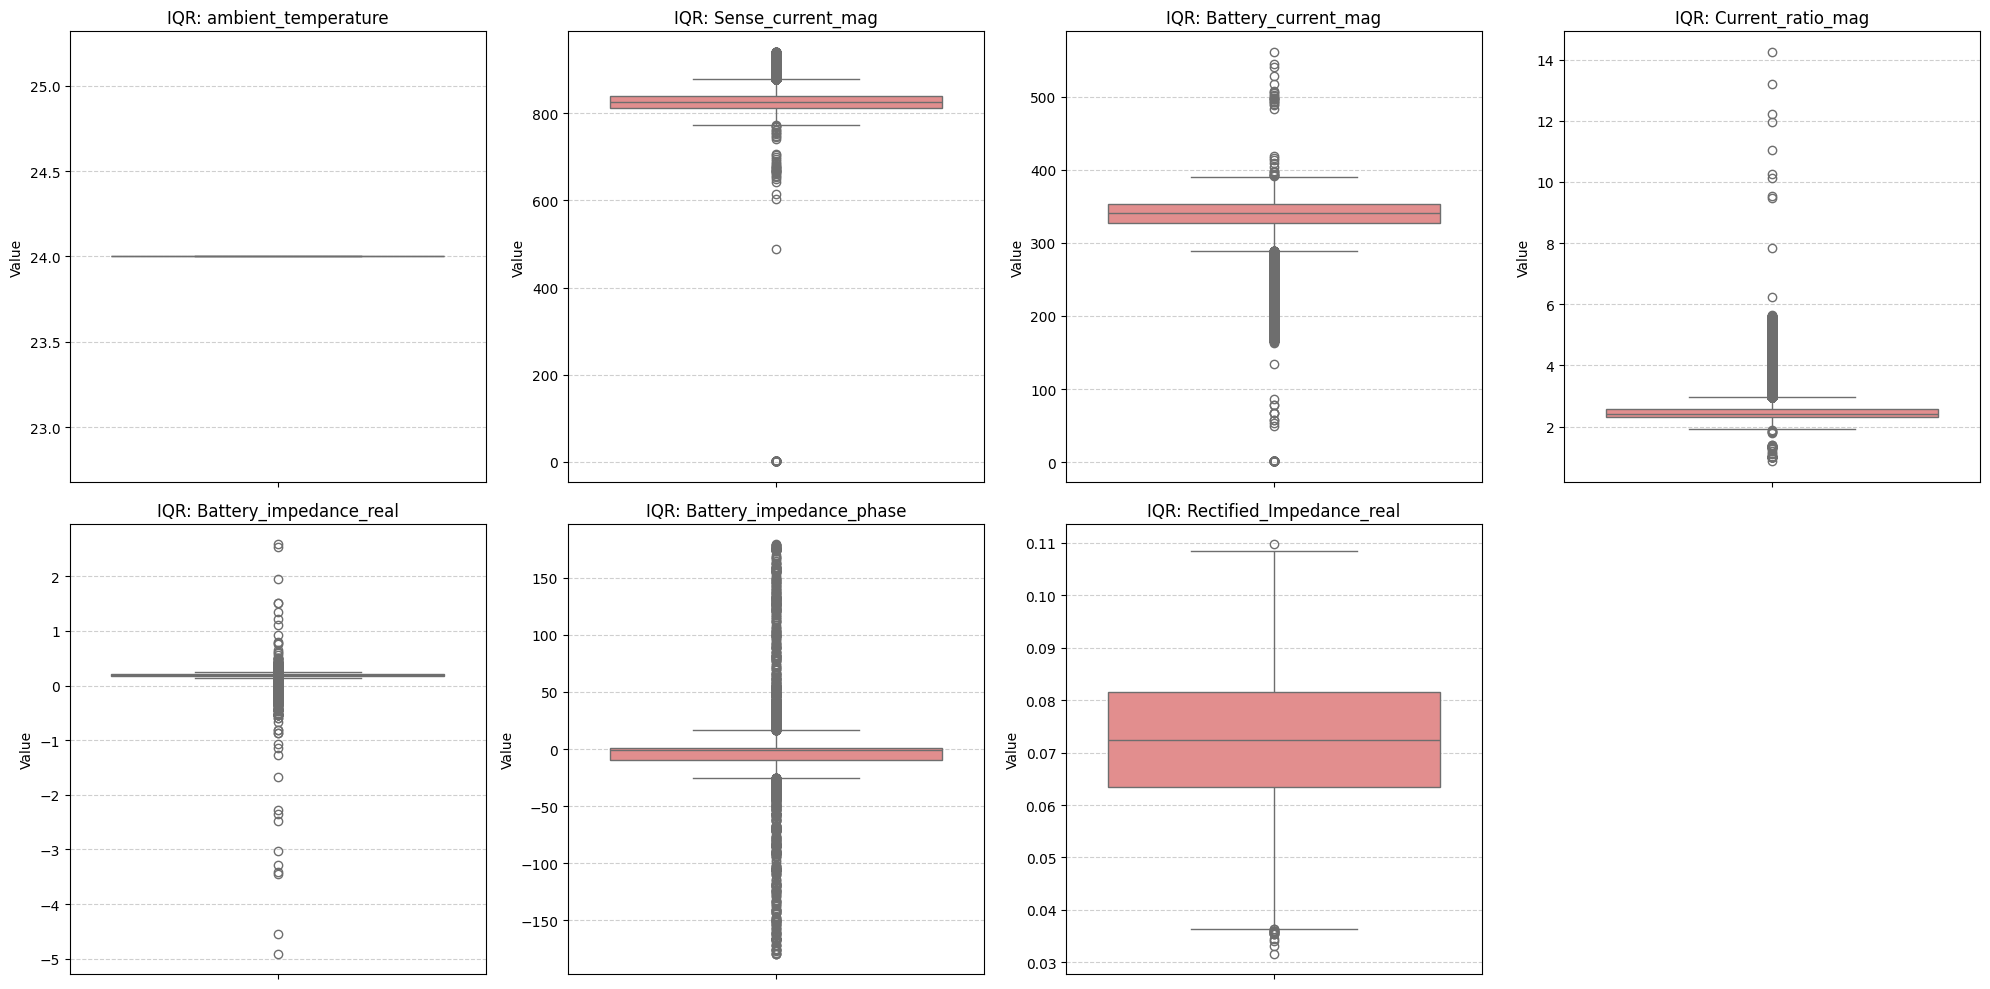

In [34]:
# 기본 칼럼에 대한 IQR

# 1. 시각화할 컬럼 리스트
target_cols = [
    'ambient_temperature', 'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]
selected_cols = [
    'cycle', 'EOL_cycle', 'RUL', 'Re', 'Rct',
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

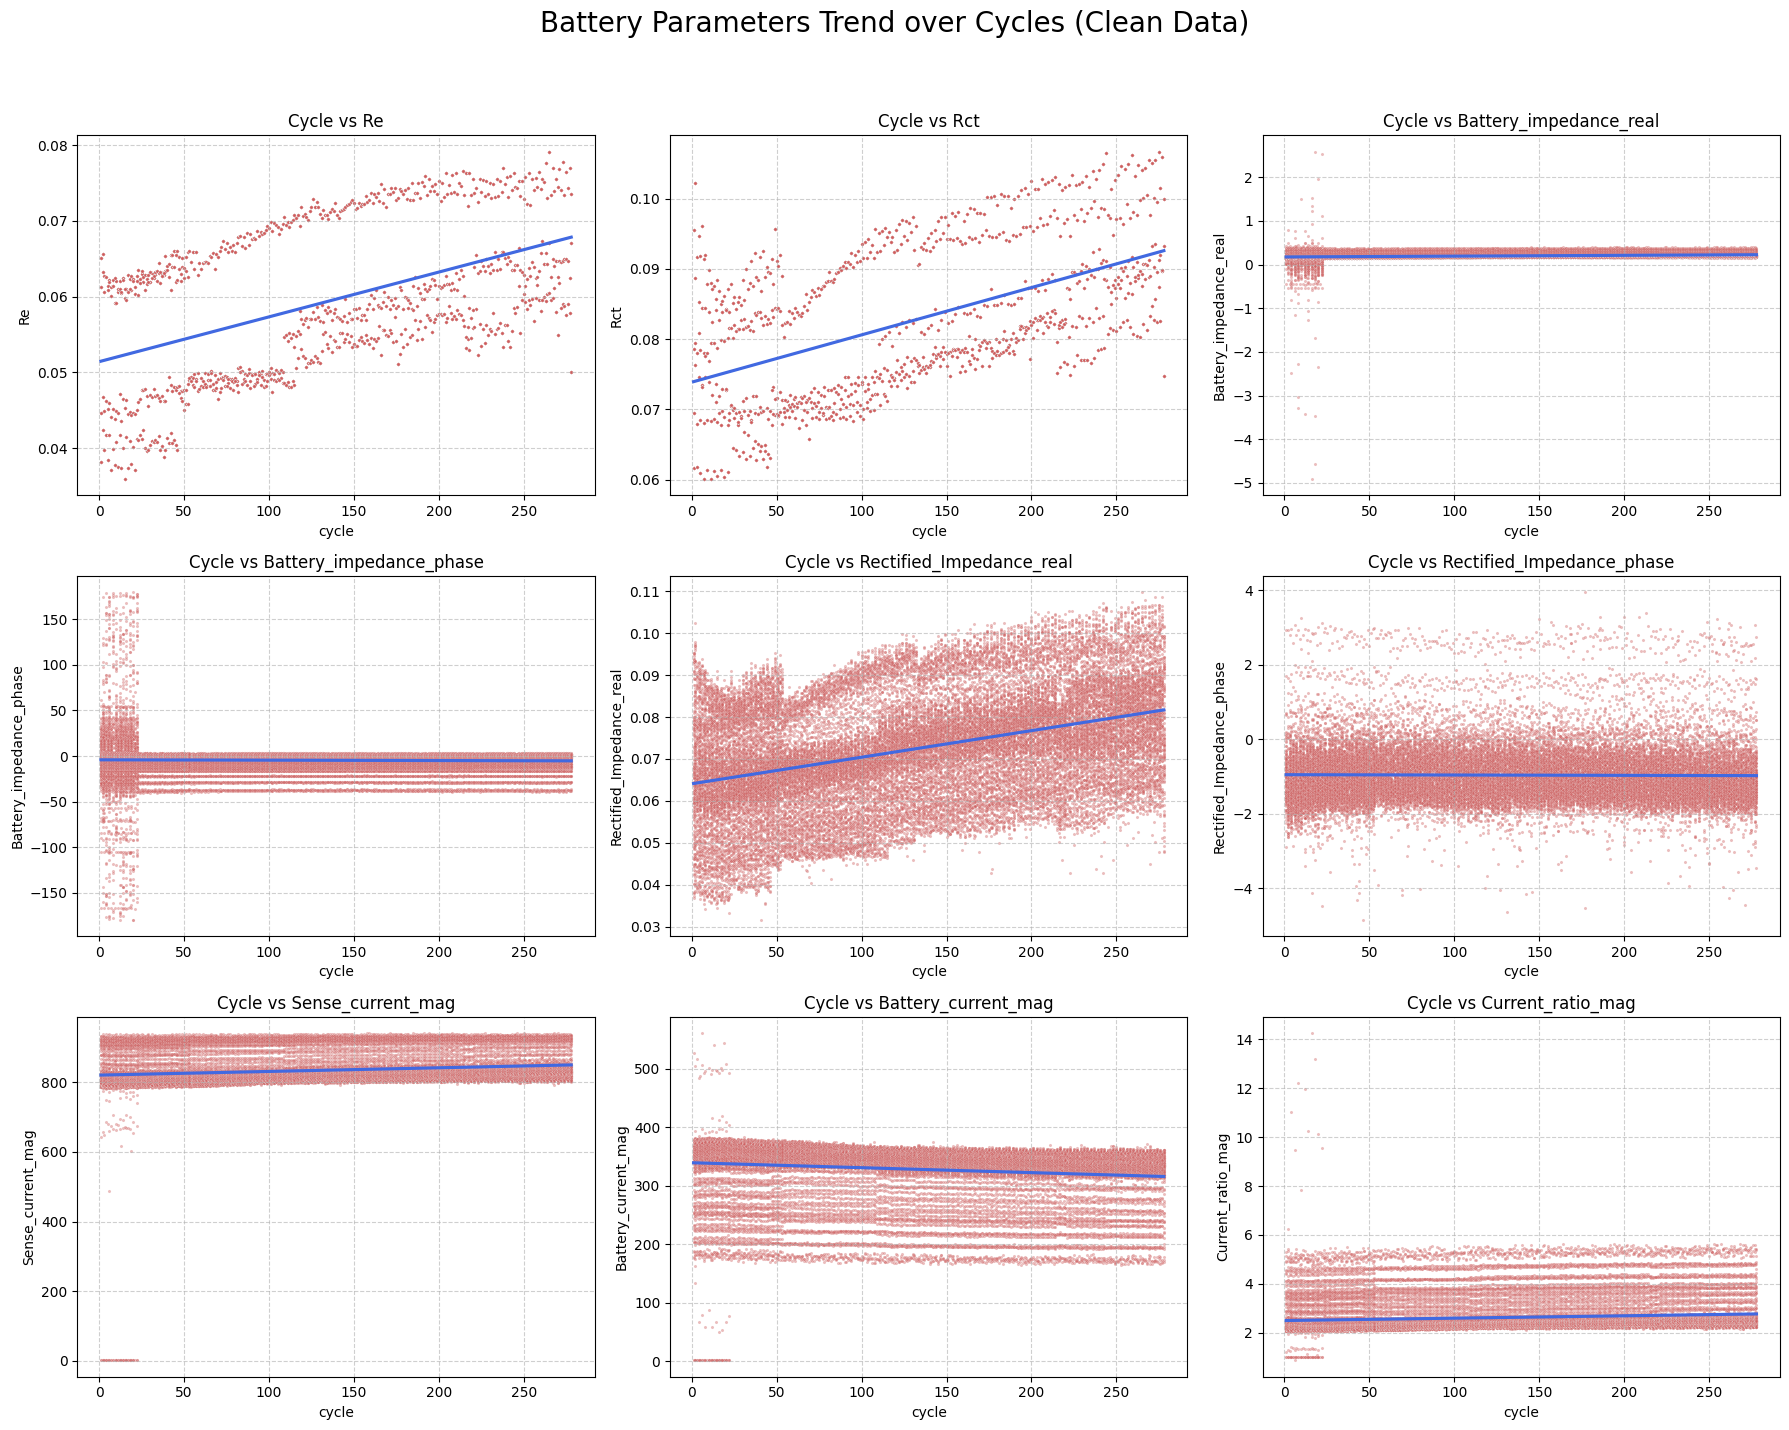

In [35]:


# 시각화할 9개 컬럼 리스트 (기존 7개 + Re, Rct)
plot_cols = [
    'Re', 'Rct', 'Battery_impedance_real', 'Battery_impedance_phase',
    'Rectified_Impedance_real', 'Rectified_Impedance_phase',
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag'
]

# 그래프 설정 (3행 3열)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Battery Parameters Trend over Cycles (Clean Data)', fontsize=20)

axes = axes.flatten()

for i, col in enumerate(plot_cols):
    # 산점도(Scatter)로 추세 확인 (점 크기 조절 s=5)
    sns.scatterplot(data=df_battery_impedance, x='cycle', y=col, 
                    ax=axes[i], s=5, alpha=0.4, color='indianred')
    
    # 추세선(Trendline) 추가 - 데이터의 흐름을 더 잘 보게 해줍니다.
    sns.regplot(data=df_battery_impedance, x='cycle', y=col, 
                ax=axes[i], scatter=False, color='royalblue')
    
    axes[i].set_title(f'Cycle vs {col}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [24]:
# 진짜 깨끗한 데이터셋 (분석용 view)
df_battery_impedance_clean = df_battery_impedance[
    (df_battery_impedance['is_valid'] == True) & 
    (df_battery_impedance['Rectified_Impedance'].notnull())
]

# 이제 이 clean_view로 describe()를 해보세요. 수치가 훨씬 정상적으로 변할 겁니다.
display(df_battery_impedance_clean[selected_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
cycle,33657.0,136.147013,80.923434,1.000000,63.000000,135.000000,207.000000,278.000000
EOL_cycle,33657.0,93.892444,25.692303,61.000000,61.000000,101.000000,124.000000,124.000000
RUL,33657.0,17.236741,28.611190,0.000000,0.000000,0.000000,30.000000,123.000000
Re,33657.0,0.059614,0.009569,0.035920,0.051890,0.059677,0.065915,0.079141
Rct,33657.0,0.083060,0.010359,0.060073,0.074792,0.082501,0.090687,0.106684


In [36]:
df_battery_impedance_clean

,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,start_time,battery_id,type,ambient_temperature,cycle,SOH,EOL_cycle,RUL,Re,Rct,Sense_current_mag,Battery_current_mag,Current_ratio_mag,Battery_impedance_real,Battery_impedance_phase,Rectified_Impedance_real,Rectified_Impedance_phase,is_valid
4,824.929504- 53.241478j,332.682678- 57.629013j,2.434305+0.261646j,0.126081-0.090444j,0.068071-0.000197j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,826.645838,337.637183,2.448326,0.126081,-35.653661,0.068071,-0.166220,True
5,824.959167- 62.825409j,333.561005- 49.793083j,2.446781+0.176901j,0.221055-0.004126j,0.066571-0.000584j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,827.347968,337.257016,2.453168,0.221055,-1.069246,0.066571,-0.502977,True
13,817.812134- 60.699287j,339.490601- 36.080208j,2.400824+0.076358j,0.222434+0.050980j,0.065518-0.001140j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,820.061638,341.402474,2.402038,0.222434,12.908798,0.065518,-0.997009,True
14,821.755432- 61.281967j,339.871887- 37.115330j,2.408803+0.082742j,0.207466+0.013882j,0.066375-0.000996j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,824.037299,341.892450,2.410224,0.207466,3.828039,0.066375,-0.859969,True
15,820.817139- 39.474792j,340.472778- 28.233839j,2.403900+0.083403j,0.188467-0.015095j,0.063634-0.001631j,2008-04-18 20:55:29,B0005,impedance,24,1,NaN,101,100,0.044669,0.069456,821.765803,341.641424,2.405346,0.188467,-4.579261,0.063634,-1.467828,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42562,796.507568- 40.968552j,368.741974- 11.972872j,2.161396-0.040924j,0.166324-0.001451j,0.067325-0.004139j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,797.560486,368.936299,2.161784,0.166324,-0.499945,0.067325,-3.518417,True
42563,793.188293- 47.088455j,370.536743- 6.832085j,2.142262-0.087582j,0.167221-0.005007j,0.065843-0.000757j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,794.584792,370.599724,2.144051,0.167221,-1.715151,0.065843,-0.658990,True
42564,796.921448- 55.883644j,368.474182+ 0.601271j,2.162507-0.155191j,0.169069-0.009110j,0.063654-0.000759j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,798.878449,368.474673,2.168069,0.169069,-3.084448,0.063654,-0.683004,True
42565,800.266113- 59.536976j,362.306274+ 4.554829j,2.206396-0.192066j,0.172064-0.013766j,0.063926+0.000191j,2008-08-20 01:34:44,B0018,impedance,24,53,NaN,75,22,0.066069,0.088959,802.477728,362.334904,2.214740,0.172064,-4.574170,0.063926,0.171489,True


In [25]:
df_battery_impedance_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33657 entries, 4 to 42566
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Sense_current              33657 non-null  complex128    
 1   Battery_current            33657 non-null  complex128    
 2   Current_ratio              33657 non-null  complex128    
 3   Battery_impedance          33657 non-null  complex128    
 4   Rectified_Impedance        33657 non-null  complex128    
 5   start_time                 33657 non-null  datetime64[ns]
 6   battery_id                 33657 non-null  object        
 7   type                       33657 non-null  object        
 8   ambient_temperature        33657 non-null  int64         
 9   cycle                      33657 non-null  int64         
 10  SOH                        0 non-null      float64       
 11  EOL_cycle                  33657 non-null  int64         
 12  RUL      

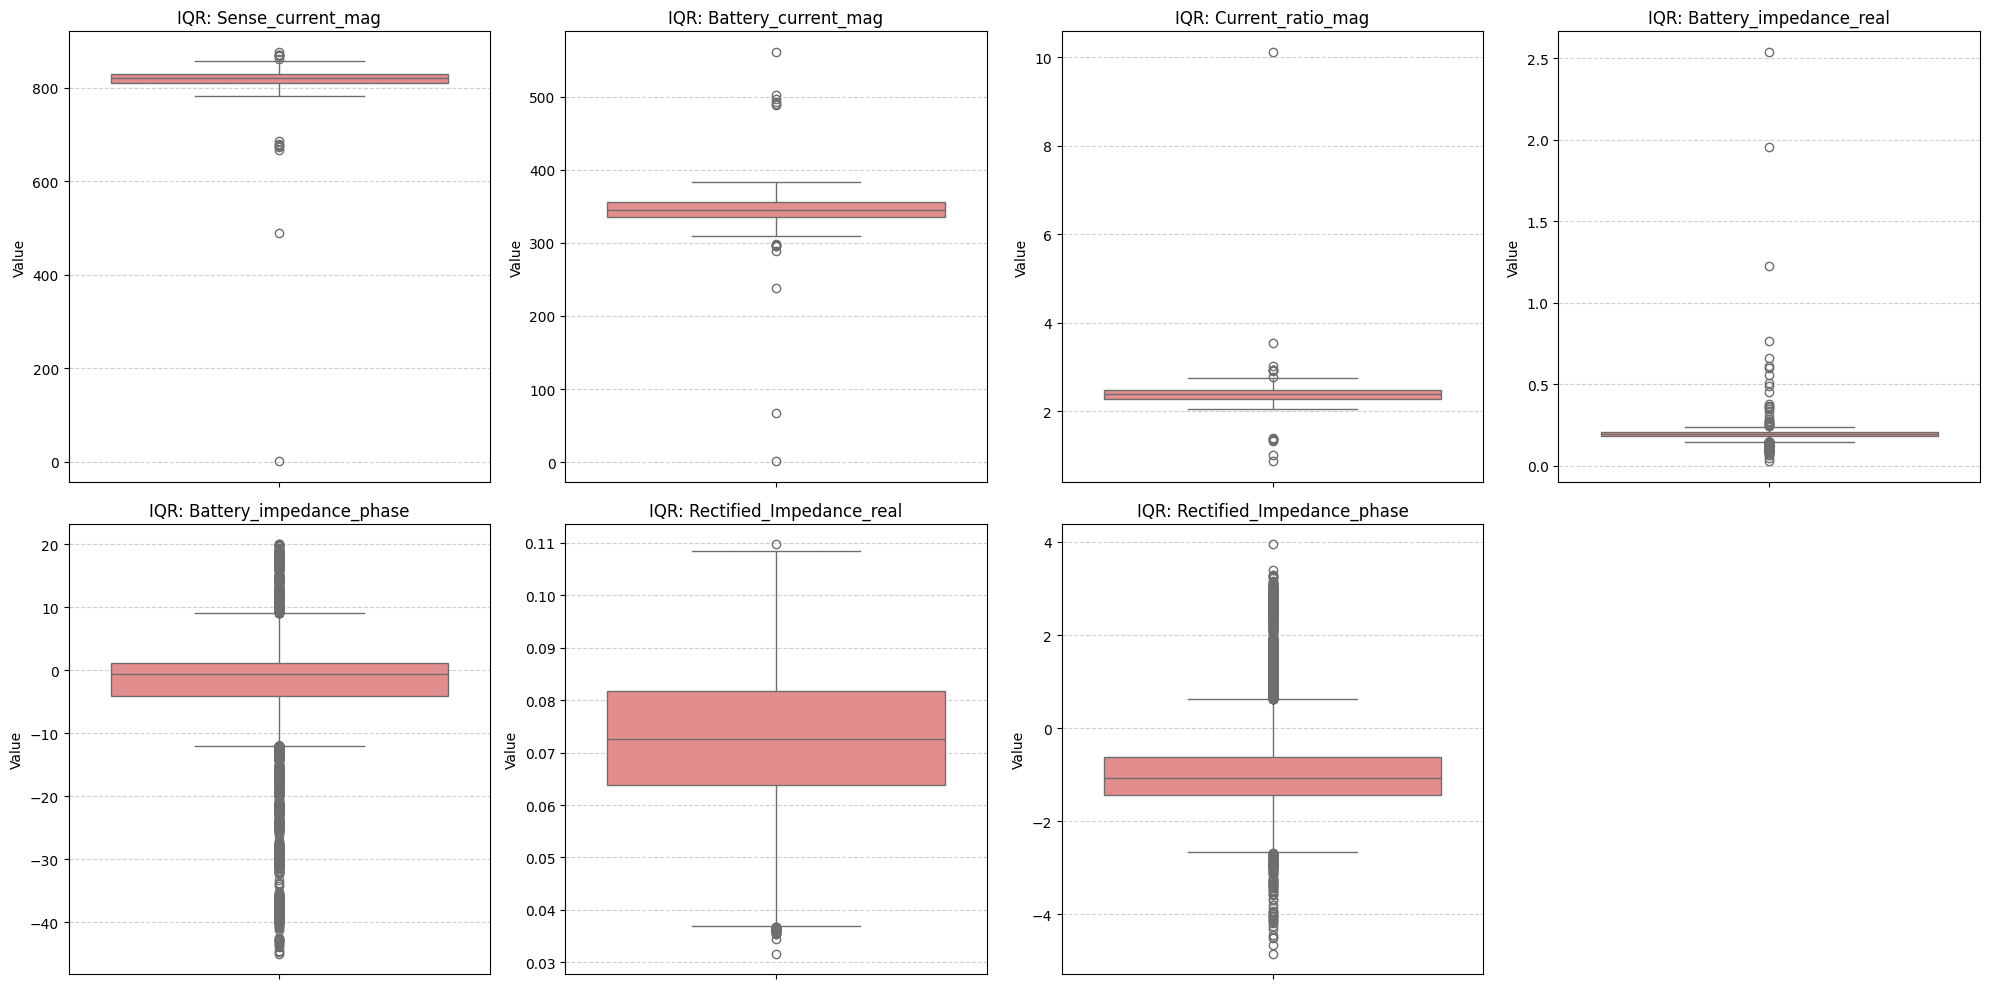

In [26]:
# 파생 칼럼에 대한 IQR

# 1. 시각화할 파생 컬럼 리스트
target_cols = [
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

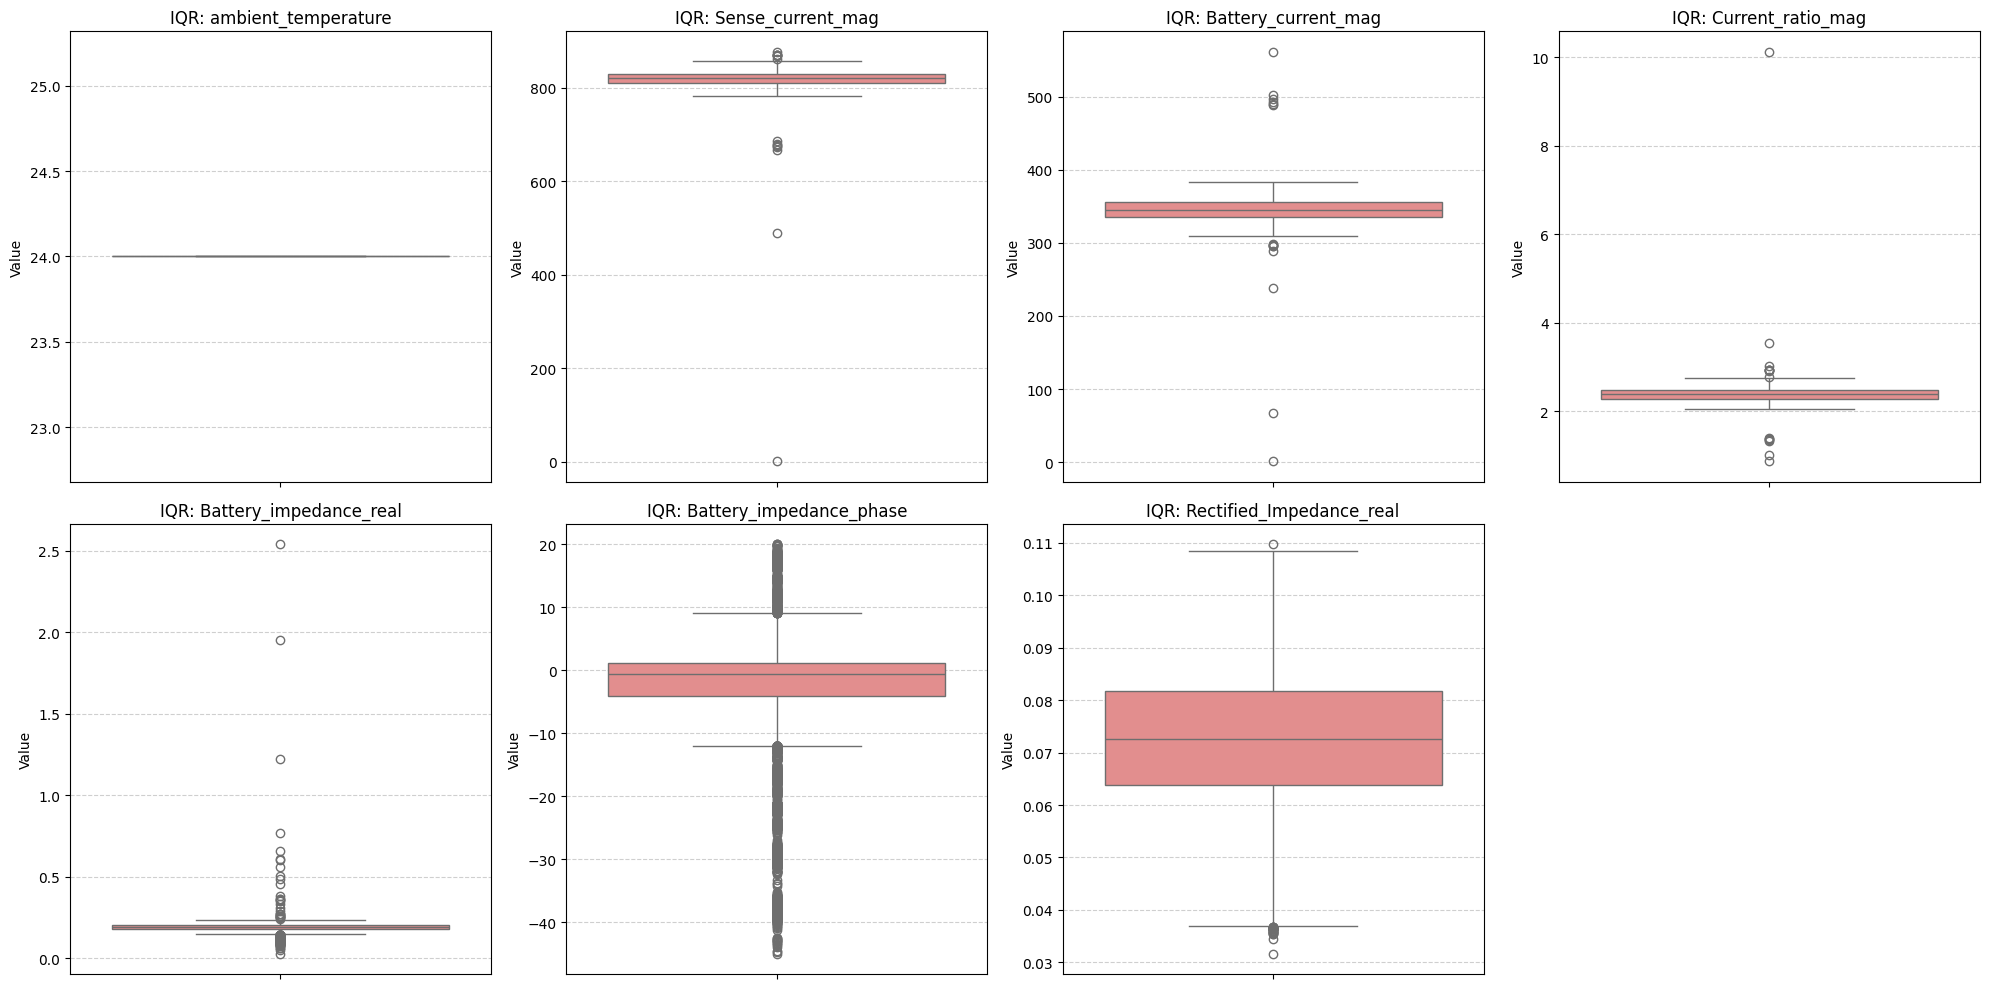

In [27]:
# 기본 칼럼에 대한 IQR

# 1. 시각화할 컬럼 리스트
target_cols = [
    'ambient_temperature', 'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag',
    'Battery_impedance_real', 'Battery_impedance_phase', 
    'Rectified_Impedance_real', 'Rectified_Impedance_phase'
]
selected_cols = [
    'cycle', 'EOL_cycle', 'RUL', 'Re', 'Rct',
]

# 2. 그래프 레이아웃 설정 (2행 4열)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() # 2D 배열을 1D로 변환하여 반복문 사용 용이하게 함

for i, col in enumerate(target_cols):
    # 박스플롯 그리기 (결측치는 자동으로 제외됨)
    sns.boxplot(y=df_battery_impedance_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'IQR: {col}', fontsize=12)
    axes[i].set_ylabel('Value')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

# 사용하지 않는 8번째 서브플롯은 삭제
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

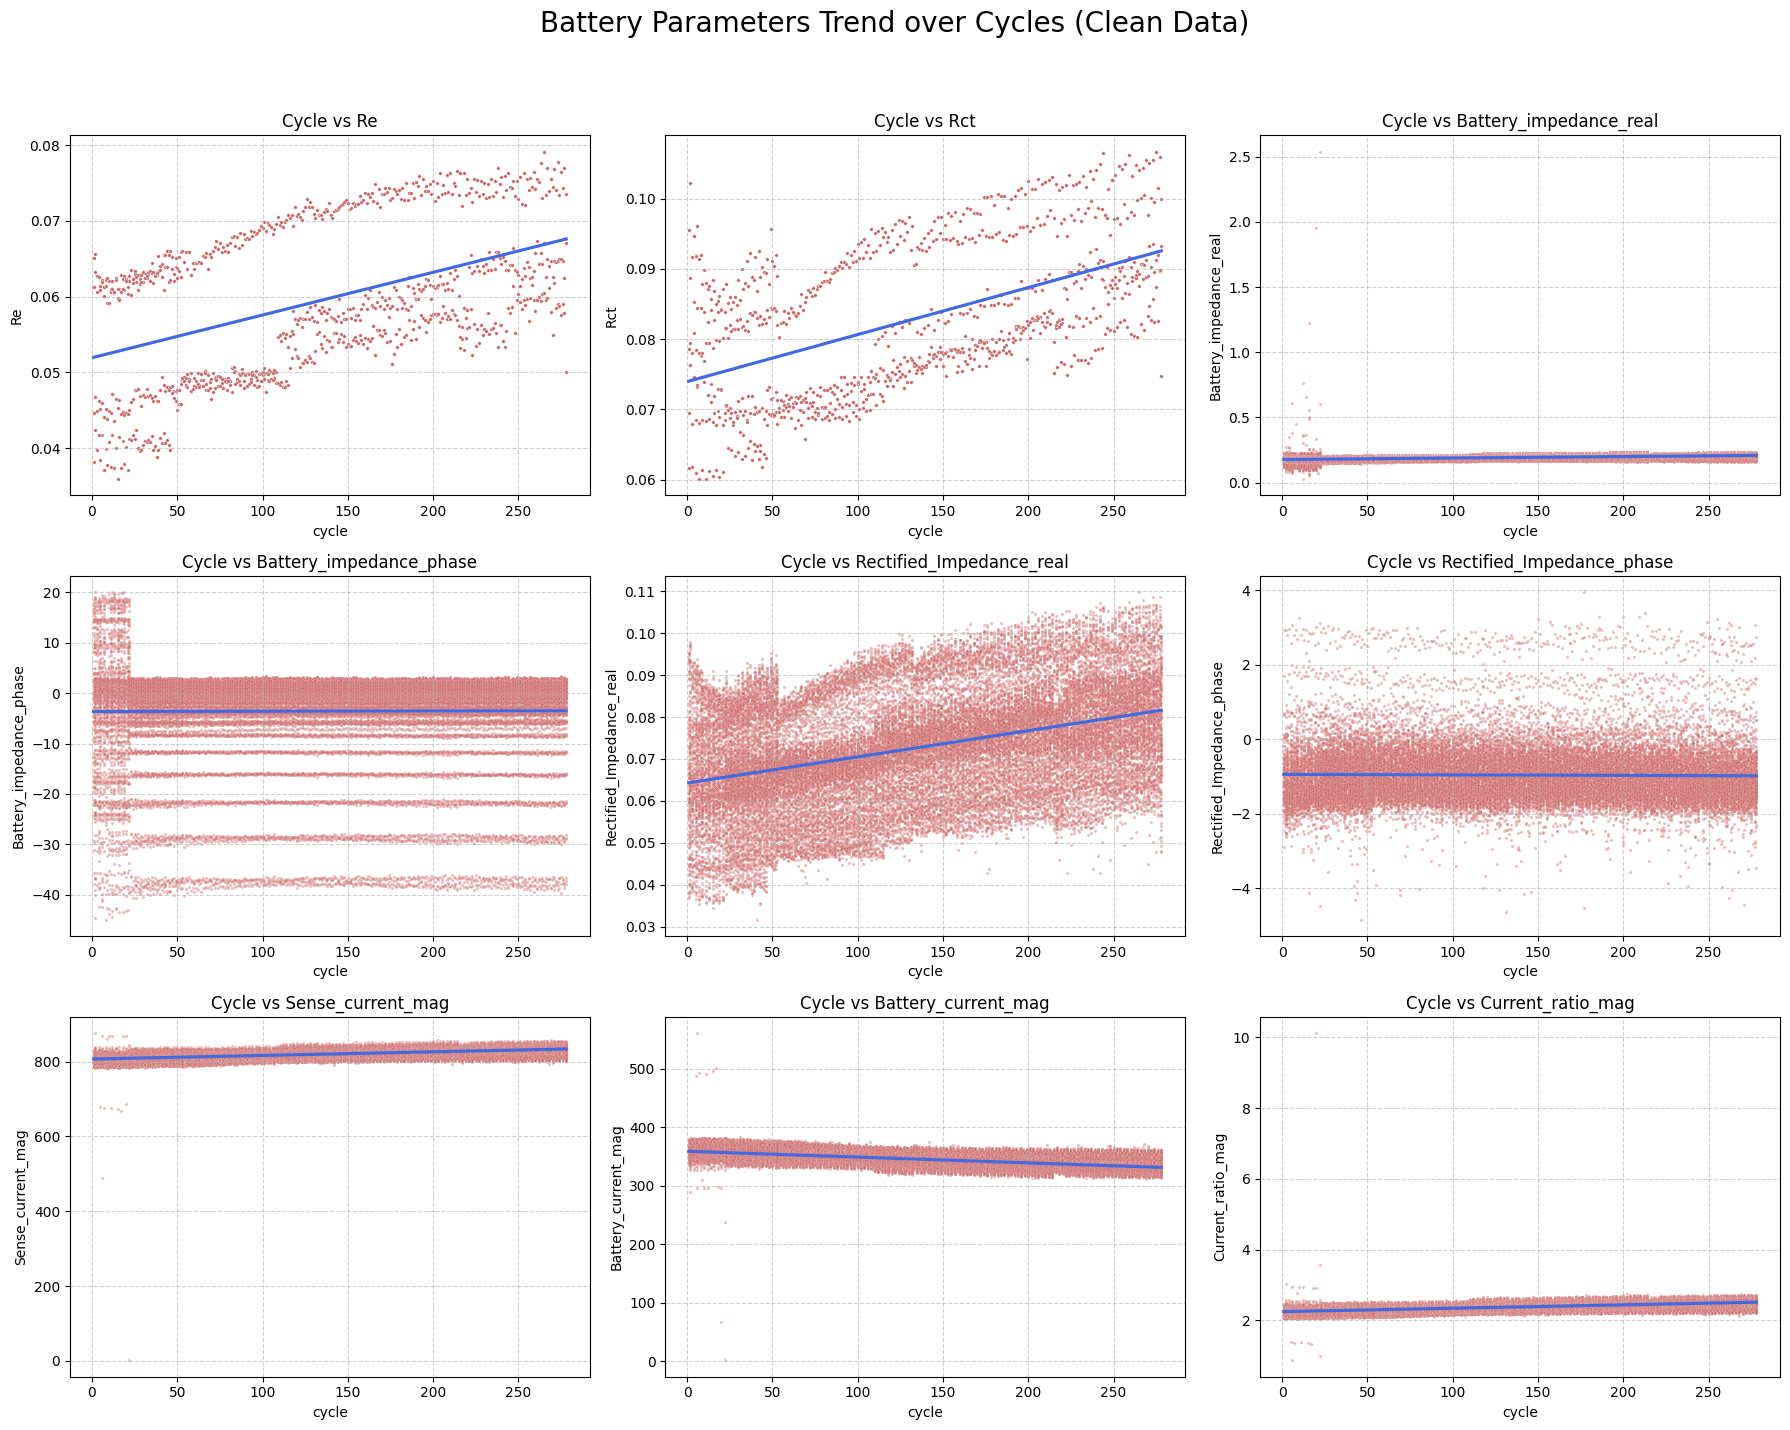

In [29]:


# 시각화할 9개 컬럼 리스트 (기존 7개 + Re, Rct)
plot_cols = [
    'Re', 'Rct', 'Battery_impedance_real', 'Battery_impedance_phase',
    'Rectified_Impedance_real', 'Rectified_Impedance_phase',
    'Sense_current_mag', 'Battery_current_mag', 'Current_ratio_mag'
]

# 그래프 설정 (3행 3열)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Battery Parameters Trend over Cycles (Clean Data)', fontsize=20)

axes = axes.flatten()

for i, col in enumerate(plot_cols):
    # 산점도(Scatter)로 추세 확인 (점 크기 조절 s=5)
    sns.scatterplot(data=df_battery_impedance_clean, x='cycle', y=col, 
                    ax=axes[i], s=5, alpha=0.4, color='indianred')
    
    # 추세선(Trendline) 추가 - 데이터의 흐름을 더 잘 보게 해줍니다.
    sns.regplot(data=df_battery_impedance_clean, x='cycle', y=col, 
                ax=axes[i], scatter=False, color='royalblue')
    
    axes[i].set_title(f'Cycle vs {col}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()